# Notebook 6.3: Advanced Signal Processing Techniques

## Financial Trading with Python, 2nd Edition

---

In Notebook 6.1, we established the statistical properties of our data. In Notebook 6.2, we applied the most accessible filtering techniques: moving averages and ARIMA. Now we move to the advanced tools: Kalman filters, Fourier transforms, wavelets, and fractional differencing.

These techniques come from engineering, physics, and signal processing research. They are mathematically sophisticated and can produce impressive results on data with known signal structures. Financial data, however, is a much harder problem. The "signal" is weak, non-stationary, and buried under noise generated by millions of market participants. Whether these tools add value beyond what we achieved with simple moving averages is an open question that we will answer honestly.

This notebook has a specific structure designed to give you both understanding and realistic expectations:

- We apply each technique to our case study data (VIX, SPY)
- We demonstrate boundary and end effects — a critical issue for live trading that is rarely covered in textbooks
- We provide side-by-side comparisons so you can see what each technique reveals or obscures

The performance comparison (does filtering actually improve strategy results?) is reserved for Notebook 6.4, where we run the VIXY strategy with each filtered signal and measure the difference.

This notebook covers:

- Kalman filters
- Fourier transforms
- Wavelets
- Fractional differencing
- Boundary effects demonstration

## Section 1: Setup and Data Loading

In [1]:
# --- Install required packages with pinned versions ---
# These are not included in the standard Colab environment.
# We pin versions to ensure reproducibility as Colab updates.
#
# filterpy: Kalman filter implementation
# PyWavelets: Wavelet transforms and denoising
# fracdiff: Not available for Python 3.10+, so we implement it manually in Section 5

!pip install filterpy==1.4.5 PyWavelets==1.6.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 27.6 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import periodogram

# Kalman filter
from filterpy.kalman import KalmanFilter

# Wavelet transforms
import pywt

# Statsmodels for ADF test (used in fractional differencing section)
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore')
sns.set_theme()

# Display settings
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

# Confirm versions
import filterpy
print(f"filterpy version: {filterpy.__version__}")
print(f"PyWavelets version: {pywt.__version__}")
print(f"Fractional differencing: custom implementation (Section 5)")

filterpy version: 1.4.5
PyWavelets version: 1.6.0
Fractional differencing: custom implementation (Section 5)


### 1.1 Loading Data

We load the same case study data and calculate the key series we will need throughout this notebook: daily returns, the 90-day SMA on VIX (our baseline to beat), and SPY realized volatility.

In [3]:
# Load aligned price data from Chapter 3
df_prices = pd.read_parquet('case_study_prices.parquet')

# Daily returns
df_returns = df_prices.pct_change().dropna()

# VIX series (used throughout this notebook)
vix = df_prices['^VIX'].copy()

# 90-day SMA on VIX — this is our baseline filter from the VIXY strategy
# Every technique in this notebook will be compared against this
vix_sma_90 = vix.rolling(window=90).mean()

# SPY 10-day annualized realized volatility (matches vixy_tail_hedge.py)
spy_realized_vol = (df_returns['SPY']
                    .rolling(window=10)
                    .std()
                    * np.sqrt(252)
                    * 100).dropna()

print(f"Data loaded: {df_prices.shape[0]} trading days")
print(f"Date range: {df_prices.index[0].strftime('%Y-%m-%d')} to "
      f"{df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"VIX mean: {vix.mean():.2f}")
print(f"Baseline: 90-day SMA on VIX")

Data loaded: 3771 trading days
Date range: 2011-01-04 to 2025-12-31
VIX mean: 18.14
Baseline: 90-day SMA on VIX


Good. Our baseline is established: the 90-day SMA on VIX with a mean of 18.14. Everything that follows gets compared against this.

## Section 2: Kalman Filters

The Kalman filter is often described as the "optimal" recursive estimator for linear systems with Gaussian noise. In less formal terms, think of it as a smart moving average that adapts its smoothing based on how much it trusts the data versus how much it trusts its own model.

A traditional moving average gives equal weight to every observation in the window (SMA) or fixed exponentially decaying weights (EMA). The Kalman filter does something fundamentally different: it maintains an estimate of the current "true" state (in our case, the underlying VIX level) and an estimate of how uncertain it is about that state. When a new observation arrives, the filter balances two sources of information:

1. **The prediction**: Where the model expected VIX to be today, based on yesterday's estimate
2. **The observation**: Where VIX actually is today

If the model is confident in its prediction (low uncertainty), it mostly ignores the new observation. If the model is uncertain, it leans heavily on the new data. This balance is controlled by two key parameters:

- **Process noise (Q)**: How much the true underlying state is expected to change from one day to the next. High Q means you expect large day-to-day shifts in the true signal, so the filter trusts new observations more.
- **Measurement noise (R)**: How noisy you believe the observations are. High R means you think the raw data is unreliable, so the filter smooths more aggressively.

The ratio of Q to R determines the filter's behavior. High Q/R produces a responsive filter (like a short moving average). Low Q/R produces a smooth filter (like a long moving average). The critical advantage over a moving average is that the Kalman filter adjusts its smoothing dynamically based on the incoming data, and it is causal — it only uses past and current observations, never future data. As we discussed in the chapter outline, this means it has no right-edge boundary problem, which is a major advantage for live trading applications.

### 2.1 Implementing a Kalman Filter on VIX

We implement a simple univariate Kalman filter on VIX levels. The state is the "true" underlying VIX level, and we treat the daily VIX closing value as a noisy observation of that state. We start with a baseline Q and R, then explore how changing them affects the output.

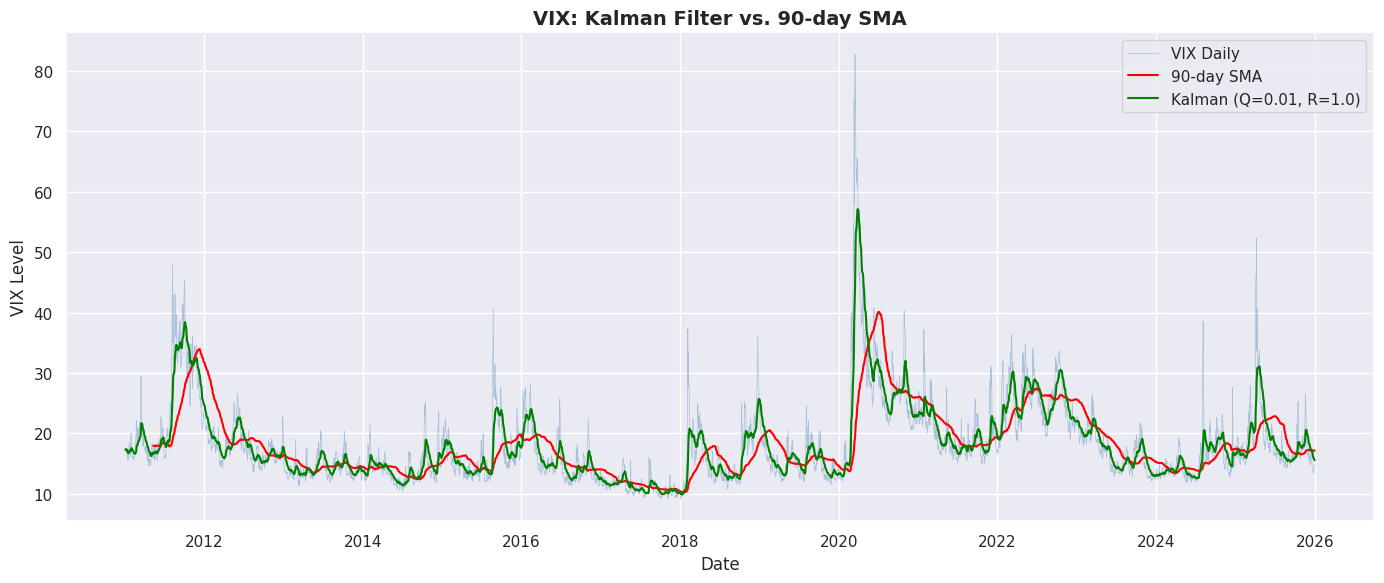

In [4]:
def apply_kalman_filter(series, process_noise=0.01, measurement_noise=1.0):
    """
    Apply a univariate Kalman filter to estimate the hidden state of a time series.

    The model assumes:
      - The true state evolves as: x_t = x_{t-1} + process_noise
      - The observation is: z_t = x_t + measurement_noise

    Parameters:
    -----------
    series : pd.Series
        The observed time series (e.g., daily VIX levels)
    process_noise : float
        Q parameter. How much the true state changes day-to-day.
        Higher = more responsive to new data, less smooth.
    measurement_noise : float
        R parameter. How noisy the observations are.
        Higher = more smoothing, less responsive.

    Returns:
    --------
    pd.Series of filtered state estimates, same index as input
    """
    # Initialize the Kalman filter
    # dim_x=1: one state variable (true VIX level)
    # dim_z=1: one measurement (observed VIX)
    kf = KalmanFilter(dim_x=1, dim_z=1)

    # State transition matrix: x_t = 1 * x_{t-1} (random walk model)
    kf.F = np.array([[1.0]])

    # Measurement matrix: z_t = 1 * x_t (we observe the state directly)
    kf.H = np.array([[1.0]])

    # Process noise covariance: how much the true state changes per step
    kf.Q = np.array([[process_noise]])

    # Measurement noise covariance: how noisy the observations are
    kf.R = np.array([[measurement_noise]])

    # Initial state estimate: start with the first observation
    kf.x = np.array([[series.iloc[0]]])

    # Initial uncertainty: start with moderate uncertainty
    # This gets corrected quickly as data arrives (the burn-in period)
    kf.P = np.array([[1.0]])

    # Run the filter forward through every observation
    filtered_values = []
    for value in series.values:
        # Predict: project state forward using the model
        kf.predict()

        # Update: incorporate the new observation
        kf.update(np.array([[value]]))

        # Store the filtered state estimate
        filtered_values.append(kf.x[0, 0])

    return pd.Series(filtered_values, index=series.index, name='Kalman')

# --- Apply Kalman filter to VIX with baseline parameters ---
# Q=0.01, R=1.0 means we trust the model more than the data,
# producing moderate smoothing. This is a reasonable starting point.
vix_kalman = apply_kalman_filter(vix, process_noise=0.01, measurement_noise=1.0)

# Quick comparison: Kalman vs 90-day SMA
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vix, color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')
ax.plot(vix_sma_90, color='red', linewidth=1.5, label='90-day SMA')
ax.plot(vix_kalman, color='green', linewidth=1.5, label='Kalman (Q=0.01, R=1.0)')

ax.set_title('VIX: Kalman Filter vs. 90-day SMA', fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

The difference in behavior is immediately visible. The Kalman filter (green) is far more responsive than the 90-day SMA (red). It tracks VIX spikes much more closely, reaching about 57 during COVID compared to the SMA's peak of roughly 40. It also reverts faster after spikes, dropping back toward the mean within weeks rather than months.

In many ways, this Kalman filter is behaving more like a short-window EMA than a 90-day SMA. With Q=0.01 and R=1.0, the filter trusts new observations fairly heavily, so it follows the data closely while still providing some smoothing. Look at the 2017-2018 calm period: the green line smooths through the minor fluctuations, but during 2011, 2015, 2020, and 2025 it reacts quickly to the spikes.

This responsiveness is a double-edged sword. The Kalman filter catches regime shifts faster (good for a tail hedge), but it also reacts to every moderate VIX bump (potentially generating false signals). Whether this tradeoff helps or hurts our VIXY strategy depends on the specific character of VIX moves: are the spikes we missed with the slow SMA worth catching, even at the cost of more false triggers? We will answer that in Notebook 6.4.

The key question right now is: how sensitive is this result to our choice of Q and R? We picked 0.01 and 1.0 as a starting point, but different values will produce very different filters. This is the parameter sensitivity problem that makes Kalman filters tricky in practice.

### 2.2 Parameter Sensitivity: The Q/R Tradeoff

The Kalman filter's behavior is controlled almost entirely by the ratio of Q (process noise) to R (measurement noise). Understanding this ratio is critical because, unlike a moving average where you choose one parameter (window length), the Kalman filter gives you two knobs to turn, and they interact. We demonstrate by applying three different Q/R ratios to VIX, ranging from aggressive (trusts data) to conservative (trusts model).

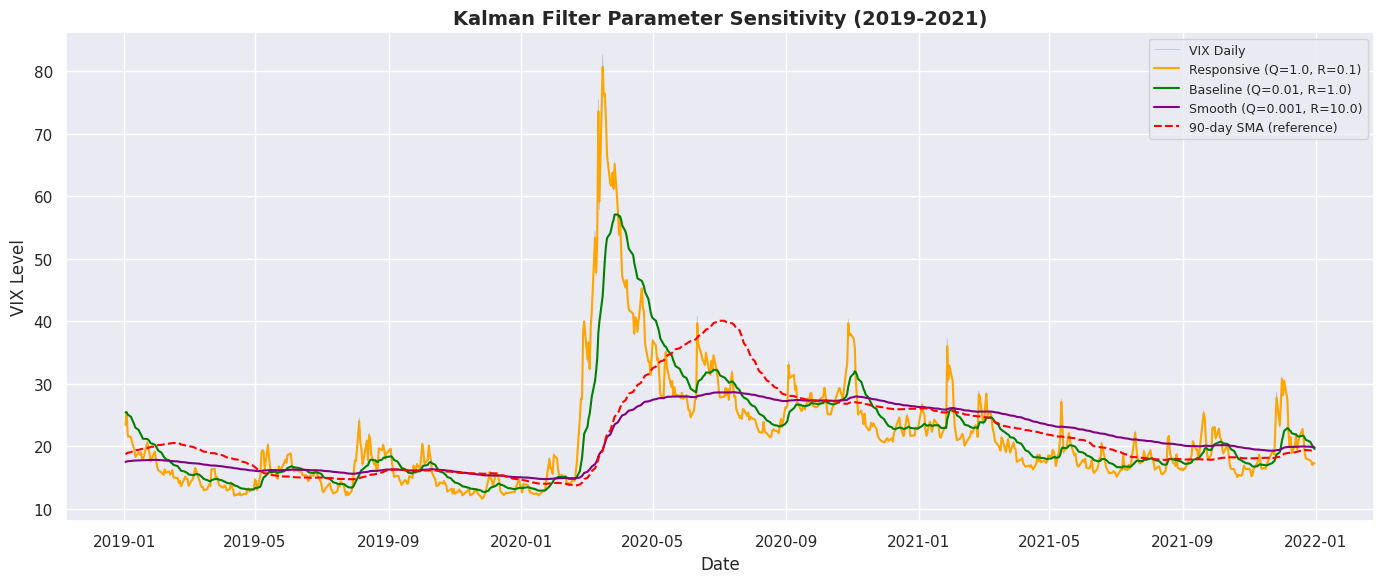

In [5]:
# --- Demonstrate Q/R sensitivity ---
# We test three configurations that span the smoothing spectrum:
#   1. High Q/R ratio (Q=1.0, R=0.1): trusts observations heavily,
#      minimal smoothing. The filter closely tracks raw data.
#   2. Baseline (Q=0.01, R=1.0): moderate smoothing.
#      This is what we used in Section 2.1.
#   3. Low Q/R ratio (Q=0.001, R=10.0): trusts the model heavily,
#      aggressive smoothing. Behaves like a long moving average.

configs = [
    {'Q': 1.0,   'R': 0.1,  'label': 'Responsive (Q=1.0, R=0.1)',   'color': 'orange'},
    {'Q': 0.01,  'R': 1.0,  'label': 'Baseline (Q=0.01, R=1.0)',    'color': 'green'},
    {'Q': 0.001, 'R': 10.0, 'label': 'Smooth (Q=0.001, R=10.0)',    'color': 'purple'},
]

# Apply Kalman filter with each configuration
kalman_results = {}
for cfg in configs:
    kalman_results[cfg['label']] = apply_kalman_filter(
        vix, process_noise=cfg['Q'], measurement_noise=cfg['R']
    )

# --- Plot all three against raw VIX ---
# Zoom into 2019-2021 to see differences clearly during COVID
mask = (vix.index >= '2019-01-01') & (vix.index <= '2021-12-31')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vix[mask], color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')

for cfg in configs:
    series = kalman_results[cfg['label']]
    ax.plot(series[mask], color=cfg['color'], linewidth=1.5, label=cfg['label'])

# Add the 90-day SMA as reference
ax.plot(vix_sma_90[mask], color='red', linewidth=1.5, linestyle='--',
        label='90-day SMA (reference)')

ax.set_title('Kalman Filter Parameter Sensitivity (2019-2021)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

This chart makes the parameter sensitivity problem visceral.

The responsive configuration (orange, Q=1.0, R=0.1) is barely filtering at all. It tracks raw VIX almost exactly, including all the daily noise in 2019 and the choppy post-COVID fluctuations. During the spike itself it nearly touches 80. This is a filter that trusts every observation and barely imposes any model structure. For a trading signal, this would generate constant churn.

The smooth configuration (purple, Q=0.001, R=10.0) goes to the opposite extreme. It barely reacts to the COVID spike, peaking around 28, and it takes until mid-2020 to get there. It then stays elevated through most of 2021, long after VIX has settled down. This is actually smoother and more lagged than the 90-day SMA (red dashed). It has effectively become an extremely long moving average with extra computational overhead.

The baseline (green, Q=0.01, R=1.0) sits in between, responding faster than the SMA but smoother than the responsive configuration. It is the most interesting of the three for our purposes, but notice how arbitrary that choice is. There is no theoretical basis for choosing Q=0.01 and R=1.0 for VIX. In engineering applications, Q and R can be estimated from the physics of the system (sensor accuracy, known process dynamics). In finance, we have no such luxury. The "true" VIX state is a concept without a physical definition, and the measurement "noise" is actually real market information.

This is the fundamental challenge with Kalman filters in finance. You are not estimating a known physical quantity corrupted by sensor noise. You are imposing a model on a system where the distinction between signal and noise is subjective. Two practitioners with different Q/R choices will get different filtered series, different signals, and different trade decisions — and neither can prove their parameters are "correct."

**Practical guidance:** If you use a Kalman filter for a trading signal, the Q and R parameters become hyperparameters of your strategy, no different from choosing a moving average window length. They must be validated out-of-sample, and you must be aware that optimizing them on historical data is a form of overfitting. The Kalman filter's theoretical claim to optimality only holds when Q and R are known, which they never are in finance. In practice, you are trading one transparent parameter (window length) for two opaque ones (Q and R), and gaining responsiveness at the cost of interpretability.

## Section 3: Fourier Transforms

The Fourier transform decomposes a time series into a sum of sine and cosine waves at different frequencies. The idea is appealing: if VIX has hidden cycles (a 30-day cycle, a 90-day cycle, a yearly cycle), Fourier analysis will find them. You could then filter out the high-frequency noise and keep only the dominant cycles, producing a clean signal.

In engineering and physics, this works beautifully. Audio signals have clear frequency content (musical notes). Radio signals have carrier frequencies. Vibration data from machinery has rotation frequencies. In all these cases, the underlying signal has genuine periodic structure that Fourier analysis is mathematically designed to extract.

Financial data is a much harder problem. Markets do not vibrate at fixed frequencies. There is no physical process generating a 47-day VIX cycle. Any periodicity that appears in historical data may be coincidental, may be regime-specific, or may disappear once enough participants start trading on it. We will apply Fourier analysis to our data honestly and see what it finds.

### 3.1 The Power Spectrum: Looking for Cycles in VIX

The power spectrum shows how much of the total variation in a series is attributable to each frequency. A tall spike in the power spectrum means there is a strong cycle at that frequency. A flat spectrum means the series is essentially random noise with no dominant cycles. We compute the power spectrum of VIX levels and SPY returns to compare a series with known structure against one without.

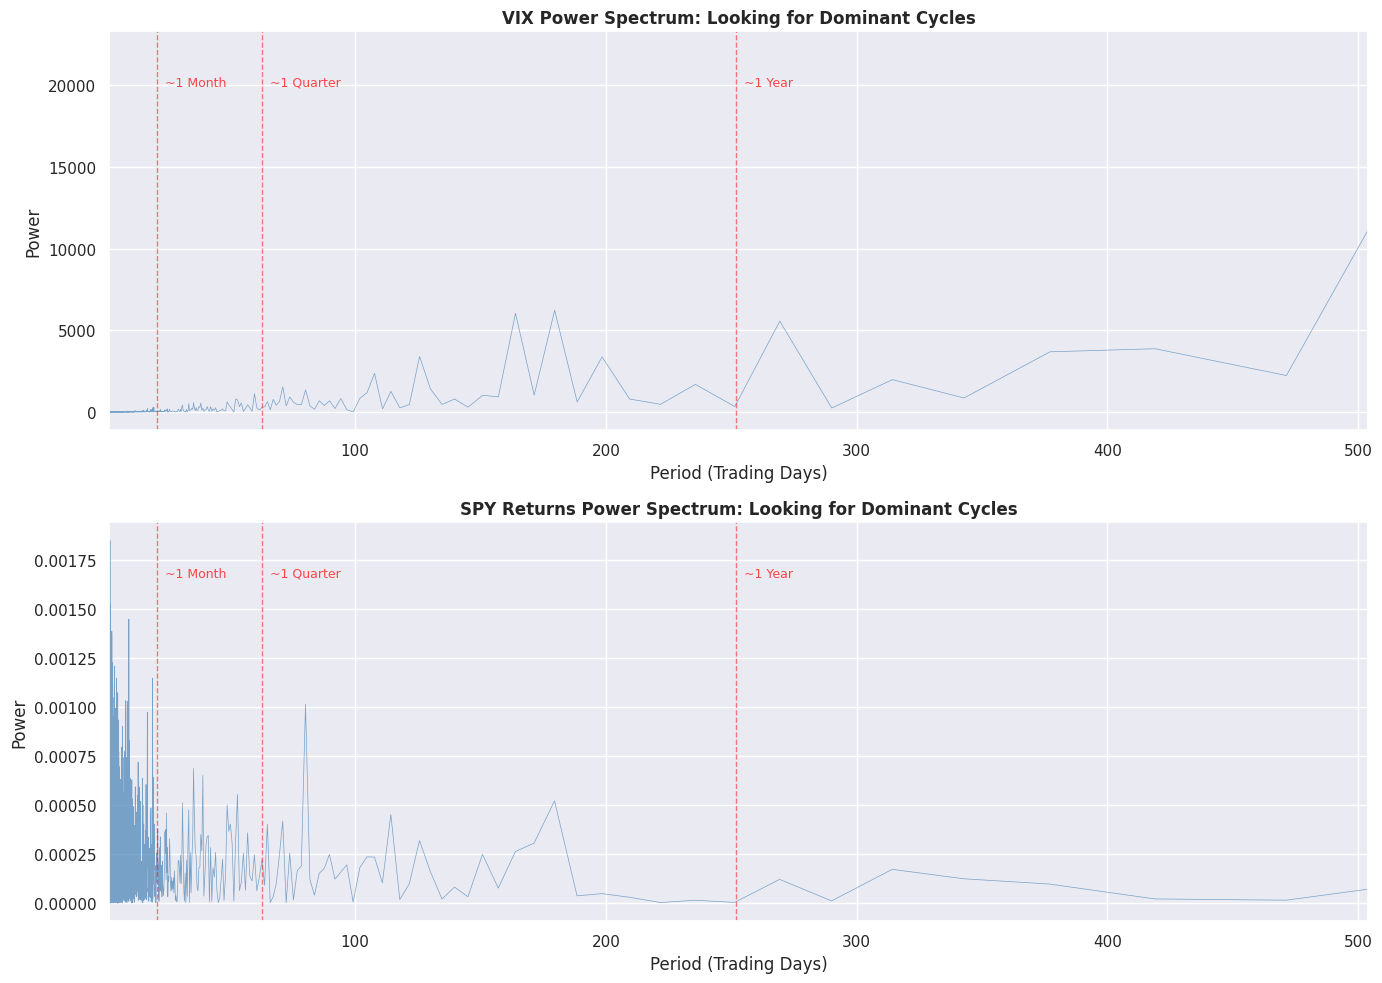

In [6]:
# --- Power spectrum of VIX levels and SPY returns ---
# We use scipy's periodogram function, which computes the power
# spectral density using the FFT (Fast Fourier Transform).
#
# The x-axis is frequency (cycles per trading day).
# A frequency of 0.05 means one cycle every 20 days.
# A frequency of 0.004 means one cycle every 250 days (~1 year).
# We convert to "period in trading days" for easier interpretation.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- VIX Levels ---
# We detrend by subtracting the mean (required for meaningful FFT)
vix_detrended = vix - vix.mean()
freqs_vix, power_vix = periodogram(vix_detrended.dropna().values, fs=1.0)

# Convert frequency to period (days per cycle) for readability
# Skip frequency=0 (the DC component / mean) to avoid division by zero
axes[0].plot(1/freqs_vix[1:], power_vix[1:], color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].set_xlim(2, 504)  # Show periods from 2 days to ~2 years
axes[0].set_xlabel('Period (Trading Days)')
axes[0].set_ylabel('Power')
axes[0].set_title('VIX Power Spectrum: Looking for Dominant Cycles',
                   fontsize=12, fontweight='bold')

# Add reference lines for common periods traders might look for
for period, label in [(21, '~1 Month'), (63, '~1 Quarter'), (252, '~1 Year')]:
    axes[0].axvline(x=period, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].text(period + 3, power_vix[1:].max() * 0.9, label,
                 fontsize=9, color='red', alpha=0.7)

# --- SPY Returns ---
freqs_spy, power_spy = periodogram(df_returns['SPY'].dropna().values, fs=1.0)

axes[1].plot(1/freqs_spy[1:], power_spy[1:], color='steelblue', linewidth=0.5, alpha=0.7)
axes[1].set_xlim(2, 504)
axes[1].set_xlabel('Period (Trading Days)')
axes[1].set_ylabel('Power')
axes[1].set_title('SPY Returns Power Spectrum: Looking for Dominant Cycles',
                   fontsize=12, fontweight='bold')

for period, label in [(21, '~1 Month'), (63, '~1 Quarter'), (252, '~1 Year')]:
    axes[1].axvline(x=period, color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].text(period + 3, power_spy[1:].max() * 0.9, label,
                 fontsize=9, color='red', alpha=0.7)

plt.tight_layout()
plt.show()

These two spectra tell very different stories, and neither one is good news for Fourier-based trading.

**VIX power spectrum** (top panel): The power increases steadily toward longer periods, with the highest concentration at periods above 400 trading days. There are some bumps around 150-180 days and a smaller one near the 1-year mark, but there are no sharp, isolated spikes that would indicate a dominant cycle. This rising power toward longer periods is the spectral signature of a persistent, autocorrelated process — exactly what we documented with the ACF in Notebook 6.1. VIX has memory, but that memory takes the form of slow mean-reversion, not repeating cycles. If there were a strong 90-day VIX cycle, we would see a sharp peak at the 1-quarter reference line. There is nothing there.

**SPY returns power spectrum** (bottom panel): Power is concentrated at very short periods (2-10 days), then the spectrum flattens out to near zero at longer periods. There is a small bump around 150-180 days, but it is tiny relative to the short-period noise. This is close to a white noise spectrum, which is what we would expect from a series with no autocorrelation. There are no hidden cycles in SPY returns waiting to be extracted by a Fourier filter.

**Why the VIX spectrum is misleading:** A reader might look at the rising power at long periods and think Fourier analysis has found something useful — VIX has strong low-frequency content. But this is not a cycle. It is the spectral manifestation of autocorrelation and mean-reversion. A mean-reverting process naturally has more power at low frequencies (slow movement) than high frequencies (fast fluctuations). A moving average captures this low-frequency content already, without the mathematical machinery or the assumptions of Fourier analysis.

**Practical guidance:** Sharp, isolated spikes in a power spectrum are what make Fourier filtering valuable — they let you surgically remove or isolate specific frequency components. Neither VIX nor SPY returns have them. This is typical of financial data at daily frequency. Fourier analysis has more legitimate applications in high-frequency data (where market microstructure can create genuine periodicity around auction times, options expiration cycles, or intraday volume patterns) and in economic data (where quarterly reporting and seasonal effects create known cycles). For daily equity and volatility data, Fourier is better as a diagnostic tool (confirming the absence of cycles, as we just did) than as a filter for generating trading signals. When we load the intraday data later for comparison, we may see a very different picture.

### 3.2 Fourier Filtering: Removing High-Frequency Noise

Even though we did not find dominant cycles, we can still use Fourier analysis as a low-pass filter: remove the high-frequency components (daily noise) and reconstruct a smoothed version of VIX. This is conceptually similar to what a moving average does, but in the frequency domain rather than the time domain. The question is whether the frequency-domain approach produces a better result.

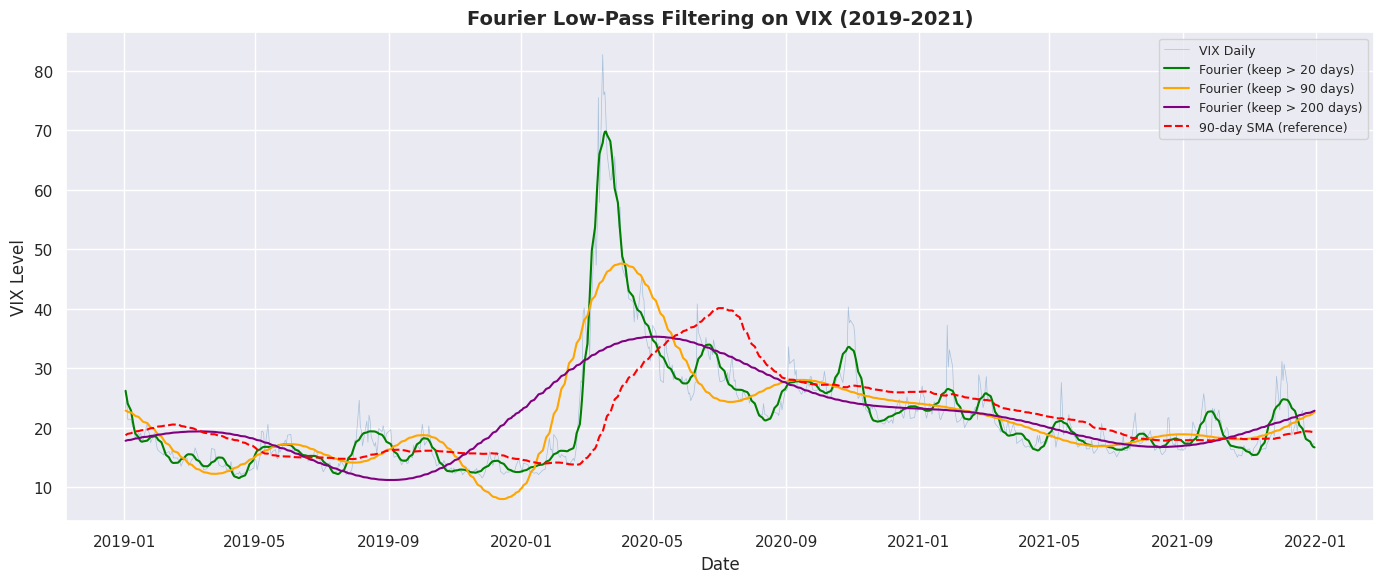

In [7]:
# --- Fourier low-pass filtering on VIX ---
# The process:
#   1. Compute the FFT (transform from time domain to frequency domain)
#   2. Zero out frequencies above a cutoff (remove high-frequency noise)
#   3. Inverse FFT to reconstruct the smoothed signal
#
# We test three cutoff periods to compare with our moving average results:
#   - Keep only periods > 20 days (aggressive filtering, like 20-day SMA)
#   - Keep only periods > 90 days (moderate, like our 90-day SMA)
#   - Keep only periods > 200 days (heavy filtering, like 200-day SMA)

def fourier_lowpass(series, min_period):
    """
    Apply a low-pass Fourier filter that removes all frequency components
    with periods shorter than min_period.

    Parameters:
    -----------
    series : pd.Series
        The input time series
    min_period : int
        Minimum period to keep (in trading days).
        Components with shorter periods are removed.

    Returns:
    --------
    pd.Series of the filtered (reconstructed) signal
    """
    values = series.values.copy()
    n = len(values)

    # Step 1: Compute the FFT
    # This transforms the time series into frequency components
    # Each component has an amplitude and phase
    fft_values = np.fft.fft(values)

    # Step 2: Compute the frequencies corresponding to each FFT component
    # fs=1.0 because our sampling rate is 1 observation per trading day
    freqs = np.fft.fftfreq(n, d=1.0)

    # Step 3: Zero out high-frequency components
    # The cutoff frequency corresponds to the minimum period we want to keep
    # frequency = 1/period, so cutoff_freq = 1/min_period
    cutoff_freq = 1.0 / min_period

    # Create a mask: keep frequencies below the cutoff (and the DC component at freq=0)
    # We use absolute value because FFT produces both positive and negative frequencies
    mask = np.abs(freqs) > cutoff_freq
    fft_filtered = fft_values.copy()
    fft_filtered[mask] = 0  # Remove high-frequency components

    # Step 4: Inverse FFT to reconstruct the smoothed signal
    # .real discards tiny imaginary artifacts from numerical precision
    filtered = np.fft.ifft(fft_filtered).real

    return pd.Series(filtered, index=series.index)

# Apply Fourier filtering at three cutoff periods
vix_fourier_20 = fourier_lowpass(vix, min_period=20)
vix_fourier_90 = fourier_lowpass(vix, min_period=90)
vix_fourier_200 = fourier_lowpass(vix, min_period=200)

# --- Plot comparison ---
mask = (vix.index >= '2019-01-01') & (vix.index <= '2021-12-31')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vix[mask], color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')
ax.plot(vix_fourier_20[mask], color='green', linewidth=1.5, label='Fourier (keep > 20 days)')
ax.plot(vix_fourier_90[mask], color='orange', linewidth=1.5, label='Fourier (keep > 90 days)')
ax.plot(vix_fourier_200[mask], color='purple', linewidth=1.5, label='Fourier (keep > 200 days)')
ax.plot(vix_sma_90[mask], color='red', linewidth=1.5, linestyle='--',
        label='90-day SMA (reference)')

ax.set_title('Fourier Low-Pass Filtering on VIX (2019-2021)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Several problems are immediately visible, and they are all instructive.

**The Fourier 90-day filter (orange) dips below 10 in late 2019**, just before the COVID spike. VIX never went below about 12 during this period, so where is this dip coming from? This is a Fourier artifact called ringing (or the Gibbs phenomenon). When you abruptly zero out frequency components, the reconstruction overshoots and undershoots around sharp transitions. The COVID spike is such an extreme, sharp event that it creates ripples in the filtered signal that propagate backward and forward in time. The filter is literally distorting the past based on knowledge of the future.

**This reveals the fundamental problem with Fourier filtering for trading.** The FFT processes the entire series at once. Every filtered value at every point in time is influenced by every observation in the dataset, including observations that have not happened yet. The smooth-looking orange curve in mid-2019 was computed using data from 2020, 2021, and beyond. In a backtest, this looks fine because all data is available. In live trading, you would recompute the FFT each day as new data arrives, and the filtered values for previous days would change. This is the boundary effects problem we flagged in the chapter outline, and we will demonstrate it concretely in Section 6.

**The Fourier 20-day filter (green)** tracks the COVID spike well, peaking around 70, but look at the oscillations throughout the series. In mid-2019 and late 2021, it wobbles above and below VIX in ways that have no market meaning. These are reconstruction artifacts from the hard frequency cutoff.

**The Fourier 200-day filter (purple)** is the smoothest, but it peaks at around 35 during COVID — months after the actual spike — and the overall shape has an unnatural, wavy quality that reflects the frequency truncation rather than genuine market dynamics.

Compare all three with the 90-day SMA (red dashed). The SMA is cruder in concept but it has none of these artifacts. It does not ring around sharp events, it does not use future data, and its behavior is transparent and predictable. The SMA is a causal filter (it only looks backward), and that property alone makes it more trustworthy for live trading than any batch Fourier filter.

**Practical guidance:** Fourier low-pass filtering on daily financial data produces results that look scientifically sophisticated but are actually less reliable than a simple moving average. The ringing artifacts, the use of future information, and the lack of dominant cycles in the data all work against it. If you see a research paper or a strategy pitch that uses Fourier-filtered prices as a trading signal, check whether the filtering was done in-sam

## Section 4: Wavelets

Wavelets address the biggest limitation of Fourier analysis: the inability to handle non-stationary data. A Fourier transform decomposes a series into frequencies that are assumed to be present throughout the entire dataset. A wavelet transform decomposes a series into frequencies localized in time — it can tell you not only what frequencies are present, but when they are present.

The intuition is this: instead of fitting infinite sine waves to the data (Fourier), wavelets use short, localized wave-like functions that are stretched and shifted across the series. Short wavelets capture high-frequency detail (daily noise). Long, stretched wavelets capture low-frequency trends. The result is a multi-scale decomposition: you can see the data at different time horizons simultaneously.

For denoising, the process is:

1. **Decompose**: Break the signal into approximation (low-frequency trend) and detail (high-frequency noise) coefficients at multiple levels
2. **Threshold**: Shrink or zero out the detail coefficients that are likely noise
3. **Reconstruct**: Rebuild the signal from the modified coefficients

The key advantage over Fourier filtering is that wavelets handle sharp transitions (like VIX spikes) much better because the localized basis functions can represent sudden changes without creating ringing artifacts across the entire series.

### 4.1 Wavelet Decomposition of VIX

We decompose VIX using the Daubechies-4 (db4) wavelet, which is a common choice for financial data because it balances smoothness with compact support (it does not spread influence too far in time). We decompose to level 4, which gives us one approximation component and four detail components, each capturing a different time scale.

In [8]:
# --- Wavelet decomposition of VIX ---
# We use the Discrete Wavelet Transform (DWT) via PyWavelets.
#
# Wavelet choice: 'db4' (Daubechies 4)
#   - Good balance between smoothness and time localization
#   - Widely used in financial applications
#   - The '4' refers to the number of vanishing moments,
#     which controls how well it represents polynomial trends
#
# Decomposition level: 4
#   Each level roughly doubles the time scale it captures:
#   - Level 1 detail (cD1): captures fluctuations ~2-4 days
#   - Level 2 detail (cD2): captures fluctuations ~4-8 days
#   - Level 3 detail (cD3): captures fluctuations ~8-16 days
#   - Level 4 detail (cD4): captures fluctuations ~16-32 days
#   - Level 4 approximation (cA4): everything slower than ~32 days (the trend)

wavelet = 'db4'
level = 4

# Perform the decomposition
# wavedec returns [cA4, cD4, cD3, cD2, cD1] — approximation first, then details
#   from coarsest to finest
coeffs = pywt.wavedec(vix.values, wavelet, level=level)

# Print the structure so readers understand what was produced
print(f"Wavelet: {wavelet}")
print(f"Decomposition level: {level}")
print(f"Original series length: {len(vix)}")
print(f"\nCoefficient arrays:")
labels = [f'cA{level}'] + [f'cD{level - i}' for i in range(level)]
for label, c in zip(labels, coeffs):
    print(f"  {label}: {len(c)} coefficients — "
          f"{'Approximation (trend)' if label.startswith('cA') else 'Detail (noise)'}")

Wavelet: db4
Decomposition level: 4
Original series length: 3771

Coefficient arrays:
  cA4: 242 coefficients — Approximation (trend)
  cD4: 242 coefficients — Detail (noise)
  cD3: 477 coefficients — Detail (noise)
  cD2: 948 coefficients — Detail (noise)
  cD1: 1889 coefficients — Detail (noise)


The decomposition split our 3,771 observations into five component arrays. Notice how each level roughly halves the number of coefficients: the detail at level 1 (cD1) has 1,889 coefficients capturing the fastest fluctuations, while the approximation at level 4 (cA4) has only 242 coefficients capturing the slow-moving trend.

Think of it as progressively zooming out. cD1 sees the day-to-day jitter. cD2 sees the weekly fluctuations. cD3 captures swings over 1-2 weeks. cD4 captures monthly-scale movements. And cA4 is the underlying trend with all faster components stripped away.

Let us reconstruct each component back to the original time scale and visualize them individually. This shows exactly what each level is capturing.

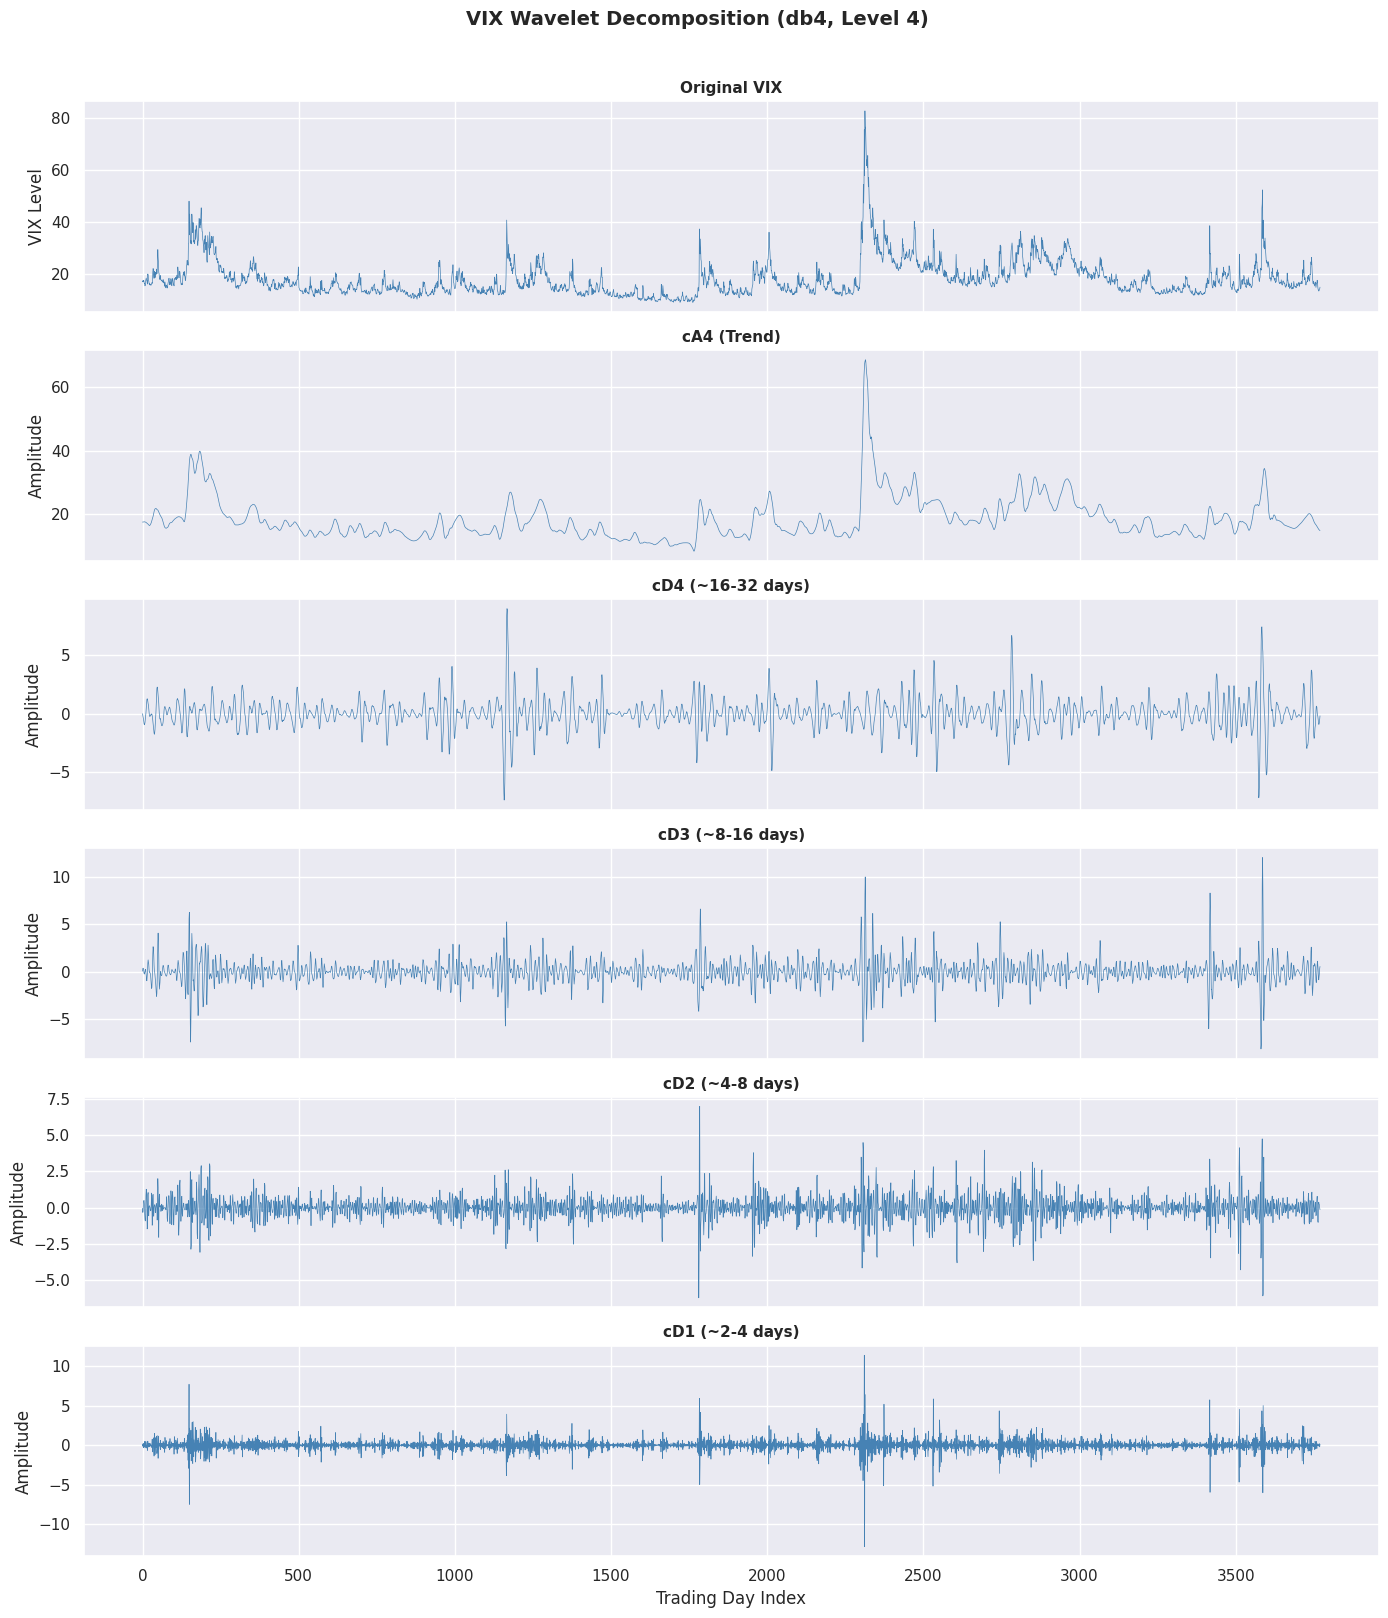

In [9]:
# --- Reconstruct each component at the original time scale ---
# To visualize individual components, we need to reconstruct each one
# separately. We do this by zeroing out all other coefficients and
# running the inverse wavelet transform.
#
# For example, to see only the cD1 (finest detail) component:
#   - Set cA4, cD4, cD3, cD2 all to zeros
#   - Keep cD1 as-is
#   - Run inverse transform

def reconstruct_component(coeffs, component_idx, wavelet):
    """
    Reconstruct a single wavelet component at the original time scale.

    Parameters:
    -----------
    coeffs : list of arrays
        Output from pywt.wavedec (full decomposition)
    component_idx : int
        Which component to reconstruct (0 = cA, 1 = cD at coarsest level, etc.)
    wavelet : str
        Wavelet name (must match what was used in decomposition)

    Returns:
    --------
    np.array of the reconstructed component at original length
    """
    # Create a copy with all coefficients set to zero
    zeroed = [np.zeros_like(c) for c in coeffs]

    # Restore only the component we want
    zeroed[component_idx] = coeffs[component_idx]

    # Inverse wavelet transform to reconstruct at original scale
    return pywt.waverec(zeroed, wavelet)

# Reconstruct all components
component_labels = [f'cA{level} (Trend)', f'cD{level} (~16-32 days)',
                    f'cD3 (~8-16 days)', f'cD2 (~4-8 days)', f'cD1 (~2-4 days)']

fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)

# Top panel: original VIX for reference
axes[0].plot(vix.values, color='steelblue', linewidth=0.5)
axes[0].set_title('Original VIX', fontsize=11, fontweight='bold')
axes[0].set_ylabel('VIX Level')

# Remaining panels: individual wavelet components
for i, (label, ax) in enumerate(zip(component_labels, axes[1:])):
    reconstructed = reconstruct_component(coeffs, i, wavelet)
    # Trim to original length (waverec can add an extra sample)
    reconstructed = reconstructed[:len(vix)]
    ax.plot(reconstructed, color='steelblue', linewidth=0.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Amplitude')

axes[-1].set_xlabel('Trading Day Index')

plt.suptitle('VIX Wavelet Decomposition (db4, Level 4)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

This decomposition is rich with information. Read it from top to bottom, moving from the original signal to progressively finer detail.

**cA4 (Trend)**: This is the slow-moving backbone of VIX. It captures the broad regime structure: the elevated volatility of 2011, the calm of 2017-2018, the COVID explosion peaking around 65, and the gradual normalization through 2021-2024. Notice how well it preserves the shape of the COVID spike while stripping away all the daily noise. Compare this with the 90-day SMA we have been using: the wavelet trend captures the spike much more faithfully because it is not constrained to a fixed window length. It adapts to the scale of the event.

**cD4 (~16-32 days)**: Monthly-scale fluctuations. These are the medium-term swings in VIX that are too fast for the trend component but too slow to be daily noise. Notice the amplitude is much larger around crisis periods (around index 200 for 2011, index 2300 for COVID) and near zero during calm markets. This is volatility clustering showing up at the monthly scale.

**cD3 (~8-16 days)**: Two-week scale fluctuations. A similar pattern of amplitude clustering during crises, but at a faster time scale. The spikes around the COVID period are enormous (reaching 10) compared to the calm of 2017 (barely visible). This scale captures the sharp initial VIX moves and their immediate aftermath.

**cD2 (~4-8 days)** and **cD1 (~2-4 days)**: The fastest components. cD1 is essentially daily noise. During calm periods, these components are tiny. During crises, they spike dramatically. This amplitude variation across time is exactly what Fourier analysis cannot capture: the "noise" is not constant. It is regime-dependent.

**The regime detection insight:** Look at the detail components (cD1 through cD4) during the COVID period. The amplitude of all four detail levels explodes simultaneously. You do not need to look at VIX itself to know something dramatic happened — the energy in the detail coefficients tells you. This is the foundation of wavelet-based regime detection: a sudden, sustained increase in detail coefficient amplitude across multiple scales signals a regime change. During calm markets, the detail amplitudes are small and stable. During crisis, they are large and volatile. This multi-scale view of regime transitions is something neither moving averages nor Kalman filters can provide, and it is a genuinely unique contribution of wavelet analysis to quantitative finance.

Now let us use this decomposition for denoising: reconstructing VIX with the noise removed.

### 4.2 Wavelet Denoising

Denoising works by thresholding the detail coefficients. The idea is straightforward: small detail coefficients are likely noise, large ones are likely signal. We shrink or zero out the small ones, keep the large ones, and reconstruct. The threshold level controls how aggressively we denoise.

There are two common thresholding approaches:

- **Hard thresholding**: Zero out any coefficient below the threshold, keep everything above unchanged. This preserves sharp features but can create discontinuities.
- **Soft thresholding**: Shrink all coefficients toward zero by the threshold amount. Coefficients below the threshold become zero, those above are reduced. This produces smoother results but slightly attenuates the signal.

We use soft thresholding, which is the more common choice for financial applications because it avoids the artifacts that hard thresholding can introduce.

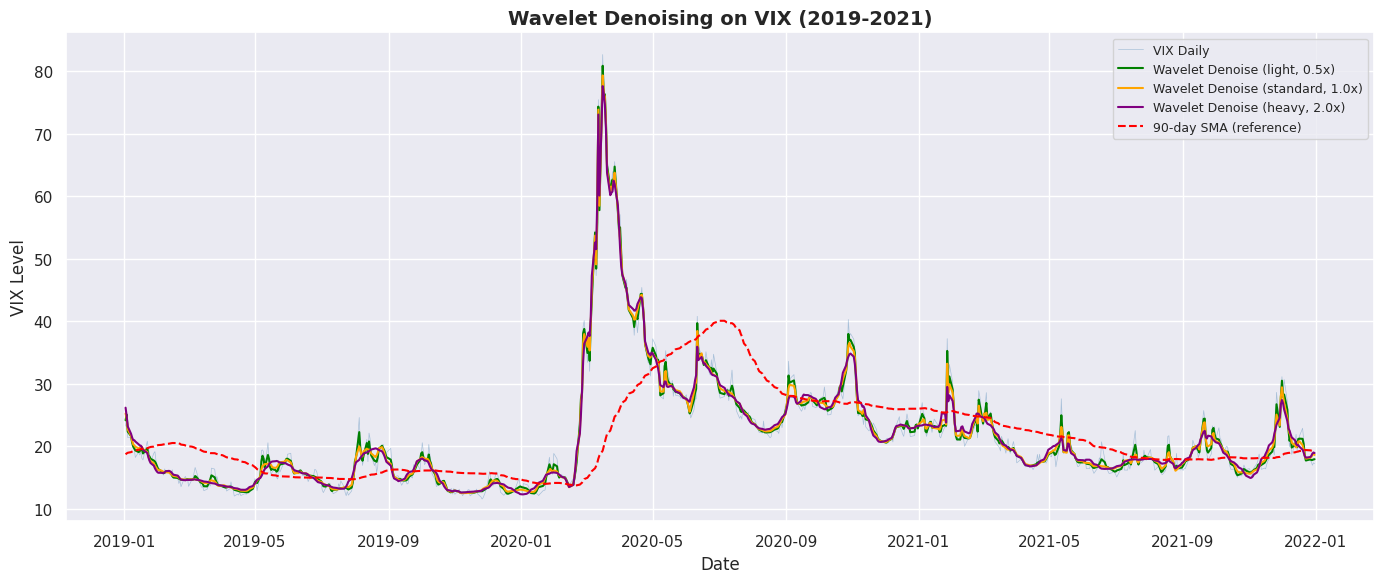

In [10]:
# --- Wavelet denoising with different threshold levels ---
# We use the universal threshold (VisuShrink), which is based on the
# noise level estimated from the finest detail coefficients (cD1).
#
# The universal threshold is: threshold = sigma * sqrt(2 * log(n))
#   where sigma is estimated from the median absolute deviation of cD1
#   and n is the length of the series.
#
# We test three multipliers of this base threshold to show the
# effect of denoising strength:
#   0.5x = light denoising (keep more detail)
#   1.0x = standard denoising
#   2.0x = aggressive denoising (remove more detail)

def wavelet_denoise(series, wavelet='db4', level=4, threshold_multiplier=1.0):
    """
    Denoise a time series using wavelet soft thresholding.

    Parameters:
    -----------
    series : pd.Series or np.array
        The input time series
    wavelet : str
        Wavelet to use for decomposition
    level : int
        Number of decomposition levels
    threshold_multiplier : float
        Multiplier for the universal threshold.
        Higher = more aggressive denoising.

    Returns:
    --------
    pd.Series of the denoised signal
    """
    values = series.values if hasattr(series, 'values') else series

    # Decompose
    coeffs = pywt.wavedec(values, wavelet, level=level)

    # Estimate noise level from the finest detail coefficients (cD1)
    # Using Median Absolute Deviation (MAD), which is robust to outliers
    # The factor 0.6745 converts MAD to an estimate of standard deviation
    # for normally distributed data
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745

    # Calculate the universal threshold (VisuShrink)
    n = len(values)
    threshold = sigma * np.sqrt(2 * np.log(n)) * threshold_multiplier

    # Apply soft thresholding to all detail coefficients (not the approximation)
    # Soft thresholding: sign(x) * max(|x| - threshold, 0)
    # This shrinks coefficients toward zero and zeros out small ones
    denoised_coeffs = [coeffs[0]]  # Keep approximation unchanged
    for detail in coeffs[1:]:
        denoised_coeffs.append(pywt.threshold(detail, threshold, mode='soft'))

    # Reconstruct
    denoised = pywt.waverec(denoised_coeffs, wavelet)

    # Trim to original length (waverec can produce one extra sample)
    denoised = denoised[:len(values)]

    if hasattr(series, 'index'):
        return pd.Series(denoised, index=series.index)
    return denoised

# Apply denoising at three threshold levels
vix_denoise_light = wavelet_denoise(vix, threshold_multiplier=0.5)
vix_denoise_standard = wavelet_denoise(vix, threshold_multiplier=1.0)
vix_denoise_heavy = wavelet_denoise(vix, threshold_multiplier=2.0)

# --- Plot comparison ---
mask = (vix.index >= '2019-01-01') & (vix.index <= '2021-12-31')

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(vix[mask], color='steelblue', linewidth=0.5, alpha=0.4, label='VIX Daily')
ax.plot(vix_denoise_light[mask], color='green', linewidth=1.5,
        label='Wavelet Denoise (light, 0.5x)')
ax.plot(vix_denoise_standard[mask], color='orange', linewidth=1.5,
        label='Wavelet Denoise (standard, 1.0x)')
ax.plot(vix_denoise_heavy[mask], color='purple', linewidth=1.5,
        label='Wavelet Denoise (heavy, 2.0x)')
ax.plot(vix_sma_90[mask], color='red', linewidth=1.5, linestyle='--',
        label='90-day SMA (reference)')

ax.set_title('Wavelet Denoising on VIX (2019-2021)', fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

The wavelet denoising results are strikingly different from both the Fourier and Kalman filters, and in some important ways, better.

Look at the COVID spike. All three denoising levels preserve the sharp shape of the event. Even the heavy denoising (purple, 2.0x threshold) peaks near 65, far higher than the SMA's 40 or the smooth Kalman's 28. The wavelet does not blur the spike into a slow hump the way a moving average does. It removes the daily jitter while keeping the dramatic structure intact. This is the key advantage of wavelet denoising over time-domain smoothing: it operates on scale rather than on a fixed window, so a sudden, legitimate event at any scale is preserved while noise at finer scales is removed.

The three threshold levels are surprisingly similar, especially compared to the dramatic differences we saw across Kalman Q/R settings. The light (green) and standard (orange) denoising are nearly indistinguishable. The heavy denoising (purple) smooths a bit more, particularly visible in mid-2019 and late 2021 where some of the smaller fluctuations are attenuated. But the overall character of the signal is stable across a wide range of threshold choices. This parameter stability is a practical advantage: the result is less sensitive to your exact settings, which reduces the risk of overfitting the denoising parameters.

Now compare with the 90-day SMA (red dashed). The SMA and the wavelets are answering fundamentally different questions. The SMA says "here is the average VIX level over the last 90 days." The wavelet says "here is VIX with the daily noise removed, at whatever level VIX actually is right now." During calm markets (2019, late 2021), the two are similar. During the COVID spike, they diverge massively. The SMA stays around 35-40 because it is averaging 90 days of history. The denoised VIX shoots to 65-75 because the spike is real signal, not noise.

For our VIXY tail hedge strategy, this is a meaningful distinction. Our current signal compares realized volatility against the 90-day SMA of VIX. A wavelet-denoised VIX would provide a much more responsive reference level during crises while still filtering out day-to-day noise during calm periods. Whether this actually improves strategy returns is the question for Notebook 6.4.

**However, there is a critical caveat.** Like Fourier analysis, the standard DWT processes the entire series at once. The denoised values we see here were computed using data from the full sample, including future data relative to any given point. This makes the chart above look better than it would in live trading. We will quantify this boundary effect problem in Section 6, and it is the main reason to be cautious about wavelet denoising for live signal generation despite the attractive visual results.

## Section 5: Fractional Differencing

The techniques we have covered so far (Kalman, Fourier, wavelets) are all about smoothing or denoising: removing noise from a series to reveal a cleaner signal. Fractional differencing addresses a completely different problem: how to make a series stationary without destroying its memory.

This is a problem we first encountered in Notebook 6.1. Recall the dilemma:

- SPY prices are non-stationary (they trend). Most models and filters require stationarity.
- The standard fix is to take returns: price today minus price yesterday (first differencing, d=1). This makes the series stationary.
- But first differencing is aggressive. It throws away all information about price levels and long-range dependencies. As we showed in Notebook 6.1, SPY returns have essentially zero autocorrelation — the memory is gone.

Fractional differencing, introduced by Granger and Joyeux (1980) and popularized in finance by Marcos Lopez de Prado in "Advances in Financial Machine Learning," offers a middle ground. Instead of differencing with d=1 (full differencing) or d=0 (no differencing), you apply a fractional order d between 0 and 1. A d of 0.3, for example, removes enough of the non-stationarity to make the series usable for modeling while preserving a significant portion of the memory (autocorrelation) that full differencing destroys.

This matters most for machine learning applications (Chapters 13-14), where you want features that are both stationary (required by most models) and informative (retaining predictive structure from price history). Fractional differencing gives you both.

### 5.1 Understanding the Weights

Since the fracdiff package is not compatible with Python 3.10+, we will implement the algorithm ourselves in the next section. Before we do, it helps to see what the weights actually look like.

Fractional differencing works by applying a series of weights to past observations. The weights come from the binomial series expansion of the differencing operator (1-B)^d, where B is the backshift operator and d is the fractional order. For integer d=1, the weights are [1, -1, 0, 0, ...], just today minus yesterday. For fractional d, the weights decay gradually, reaching further back into history. The smaller d is, the slower the weights decay, and the more history is retained.

In practice, we truncate the weights once they become negligibly small (below a threshold), since the weights decay to zero but never quite reach it. The code below computes the first ten weights for several values of d to show the pattern.

In [11]:
# --- Demonstrate the weights for different d values ---
# Before implementing the full algorithm, it helps to see what the weights
# actually look like. The weights follow the recursive formula:
#   w_0 = 1
#   w_k = -w_{k-1} * (d - k + 1) / k
# Computing the first 10 weights for several d values shows how the
# memory profile changes with d. Small d gives slowly decaying weights
# (long memory preserved), large d gives quickly decaying weights
# (memory destroyed quickly). This is the entire intuition behind
# fractional differencing in one table.
print("Fractional Differencing Weights (first 10)")
print("=" * 65)
for d in [0.2, 0.4, 0.6, 0.8, 1.0]:
    weights = [1.0]
    for k in range(1, 10):
        weights.append(-weights[-1] * (d - k + 1) / k)
    weight_str = ', '.join([f'{w:>7.4f}' for w in weights])
    print(f"d={d:.1f}: [{weight_str}]")

print(f"\nNotice: d=1.0 gives [1, -1, 0, 0, ...], standard first differencing")
print(f"        d=0.2 gives weights that decay very slowly, long memory preserved")

Fractional Differencing Weights (first 10)
d=0.2: [ 1.0000, -0.2000, -0.0800, -0.0480, -0.0336, -0.0255, -0.0204, -0.0169, -0.0144, -0.0125]
d=0.4: [ 1.0000, -0.4000, -0.1200, -0.0640, -0.0416, -0.0300, -0.0230, -0.0184, -0.0152, -0.0128]
d=0.6: [ 1.0000, -0.6000, -0.1200, -0.0560, -0.0336, -0.0228, -0.0168, -0.0129, -0.0103, -0.0085]
d=0.8: [ 1.0000, -0.8000, -0.0800, -0.0320, -0.0176, -0.0113, -0.0079, -0.0059, -0.0045, -0.0036]
d=1.0: [ 1.0000, -1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]

Notice: d=1.0 gives [1, -1, 0, 0, ...], standard first differencing
        d=0.2 gives weights that decay very slowly, long memory preserved


The weight table makes the algorithm concrete. At d=1.0, you get the familiar first difference: today's value minus yesterday's value, with zero weight on everything else. All memory of price levels is destroyed in a single subtraction.

At d=0.2, the story is very different. Today's value gets a weight of 1.0, yesterday gets -0.2, the day before gets -0.08, and the weights continue decaying slowly. After 10 lags, the weight is still -0.0125 — small but not zero. These trailing weights mean the fractionally differenced value retains information about price levels from weeks and months ago. The series has been nudged toward stationarity without being stripped of its history.

Notice the pattern: as d increases, the first lag weight gets larger (more aggressive differencing) but the subsequent weights get smaller (less trailing memory). At d=1.0, all the differencing happens in one step. At lower d values, the differencing is spread across many lags, preserving the long-range structure.

Now let us apply this to SPY prices and see the effect on both stationarity and autocorrelation.

### 5.2 Finding the Right d: Balancing Stationarity and Memory

Now we implement the algorithm and put it to work. The goal is to find the minimum d that makes the series stationary. Lower d preserves more memory, but if d is too low, the series remains non-stationary and unusable for modeling. We apply fractional differencing to SPY prices at multiple d values and test each for stationarity using the ADF test from Notebook 6.1.

The implementation adds one practical safeguard to the basic algorithm: a `max_window` parameter that caps the number of weights computed. At low d values, the weights decay so slowly that the convergence threshold alone can require thousands of lags. A cap of 500 trading days (roughly two years) preserves meaningful long-range memory while keeping the lookback period and compute time bounded.

In [12]:
def fractional_diff(series, d, threshold=1e-5, max_window=500):
    """
    Apply fractional differencing of order d to a time series.

    Uses the expanding window method with weight truncation.
    Weights come from the binomial series: w_k = -w_{k-1} * (d - k + 1) / k

    Parameters:
    -----------
    series : pd.Series
        The input time series (e.g., prices)
    d : float
        Fractional differencing order (0 < d < 1).
        d=0: no differencing (original series)
        d=1: standard first differencing (returns)
        d=0.3-0.5: typical range that balances stationarity and memory
    threshold : float
        Stop computing weights when they fall below this value.
        Smaller threshold = longer memory but more computation.
    max_window : int
        Maximum number of weights to compute. Prevents excessively
        long lookback periods at low d values where weights decay
        very slowly. Default 500 trading days (~2 years).

    Returns:
    --------
    pd.Series of the fractionally differenced series
    """
    # Step 1: Compute the weights
    # The weights follow the recursive formula:
    #   w_0 = 1
    #   w_k = -w_{k-1} * (d - k + 1) / k
    # For d=1: weights = [1, -1, 0, 0, ...] (standard differencing)
    # For d=0.5: weights decay slowly, e.g. [1, -0.5, -0.125, -0.0625, ...]
    weights = [1.0]
    k = 1
    while k < max_window:
        w = -weights[-1] * (d - k + 1) / k
        if abs(w) < threshold:
            break
        weights.append(w)
        k += 1

    weights = np.array(weights)
    width = len(weights)

    # Step 2: Apply weights as a dot product with past observations
    # For each time t, the fractionally differenced value is:
    #   y_t = w_0 * x_t + w_1 * x_{t-1} + w_2 * x_{t-2} + ...
    # This is a convolution with the weight vector
    values = series.values
    result = np.full(len(values), np.nan)

    for t in range(width - 1, len(values)):
        # Dot product of weights with the current and past observations
        result[t] = np.dot(weights, values[t - width + 1:t + 1][::-1])

    return pd.Series(result, index=series.index, name=f'frac_diff_d={d}')

print("fractional_diff function defined with max_window=500 (~2 years of trading days)")

fractional_diff function defined with max_window=500 (~2 years of trading days)


In [13]:
# --- Apply fractional differencing at multiple d values ---
# For each d, we:
#   1. Compute the fractionally differenced series
#   2. Run the ADF test to check stationarity
#   3. Compute the autocorrelation at lag 1 to measure remaining memory
#
# We test d from 0.1 to 1.0 in steps of 0.1

spy_prices = df_prices['SPY'].copy()

print("Fractional Differencing: Stationarity vs. Memory")
print("=" * 70)
print(f"{'d':<6} {'ADF Statistic':>14} {'ADF p-value':>14} {'Stationary?':>14} {'ACF(1)':>10}")
print("-" * 70)

frac_diff_results = {}
for d in np.arange(0.1, 1.1, 0.1):
    d = round(d, 1)  # Avoid floating point artifacts

    # Apply fractional differencing
    fd_series = fractional_diff(spy_prices, d=d)
    fd_clean = fd_series.dropna()

    # ADF test for stationarity
    adf_result = adfuller(fd_clean, autolag='AIC')
    adf_stat = adf_result[0]
    adf_pvalue = adf_result[1]
    is_stationary = 'Yes' if adf_pvalue < 0.05 else 'No'

    # Autocorrelation at lag 1 (measure of remaining memory)
    acf_1 = fd_clean.autocorr(lag=1)

    frac_diff_results[d] = {
        'series': fd_series,
        'adf_stat': adf_stat,
        'adf_pvalue': adf_pvalue,
        'stationary': is_stationary,
        'acf_1': acf_1
    }

    print(f"{d:<6} {adf_stat:>14.4f} {adf_pvalue:>14.6f} {is_stationary:>14} {acf_1:>10.4f}")

print(f"\nFor reference:")
print(f"  d=0.0 (raw prices): ACF(1) ≈ 1.000, non-stationary")
print(f"  d=1.0 (returns):    ACF(1) close to 0, stationary but memory destroyed")

Fractional Differencing: Stationarity vs. Memory
d       ADF Statistic    ADF p-value    Stationary?     ACF(1)
----------------------------------------------------------------------
0.1            0.8429       0.992299             No     0.9989
0.2            0.0483       0.962346             No     0.9957
0.3           -0.8198       0.813237             No     0.9836
0.4           -1.8646       0.348870             No     0.9404
0.5           -3.0982       0.026684            Yes     0.8170
0.6           -4.7266       0.000075            Yes     0.5915
0.7           -6.4057       0.000000            Yes     0.3636
0.8           -8.0665       0.000000            Yes     0.1780
0.9           -9.8705       0.000000            Yes     0.0346
1.0          -11.8879       0.000000            Yes    -0.0780

For reference:
  d=0.0 (raw prices): ACF(1) ≈ 1.000, non-stationary
  d=1.0 (returns):    ACF(1) close to 0, stationary but memory destroyed


This table is the core result of the fractional differencing section. Read the two right-hand columns together — they tell the full story.

At d=0.1 and d=0.2, the series is still non-stationary (high p-values) but the autocorrelation at lag 1 is nearly 1.0 — almost all memory is preserved. We have barely touched the data.

At d=0.3 and d=0.4, we are getting closer to stationarity (p-values dropping) but still not there. Memory is declining but remains strong: ACF(1) of 0.98 and 0.94 respectively.

At **d=0.5, we cross the threshold**. The ADF p-value drops to 0.027, just below 0.05 — the series is stationary. And the lag-1 autocorrelation is 0.817. Compare that with d=1.0 (standard returns) where ACF(1) is -0.078, essentially zero. At d=0.5, we have achieved stationarity while preserving the vast majority of the memory structure. This is the sweet spot.

At d=0.6 through d=0.9, stationarity gets stronger but memory decays rapidly. By d=0.9, ACF(1) is only 0.035 — nearly as memoryless as full returns. The marginal stationarity improvement is not worth the memory loss.

The minimum d that achieves stationarity for SPY is 0.5. This means we can create a version of SPY that is stationary enough for modeling but retains an autocorrelation of 0.817 — rich, persistent structure that standard returns completely destroy. For a machine learning model trying to predict future SPY behavior, a fractionally differenced feature at d=0.5 contains far more usable information than a simple return.

Let us visualize what the fractionally differenced series actually looks like at the key d values.

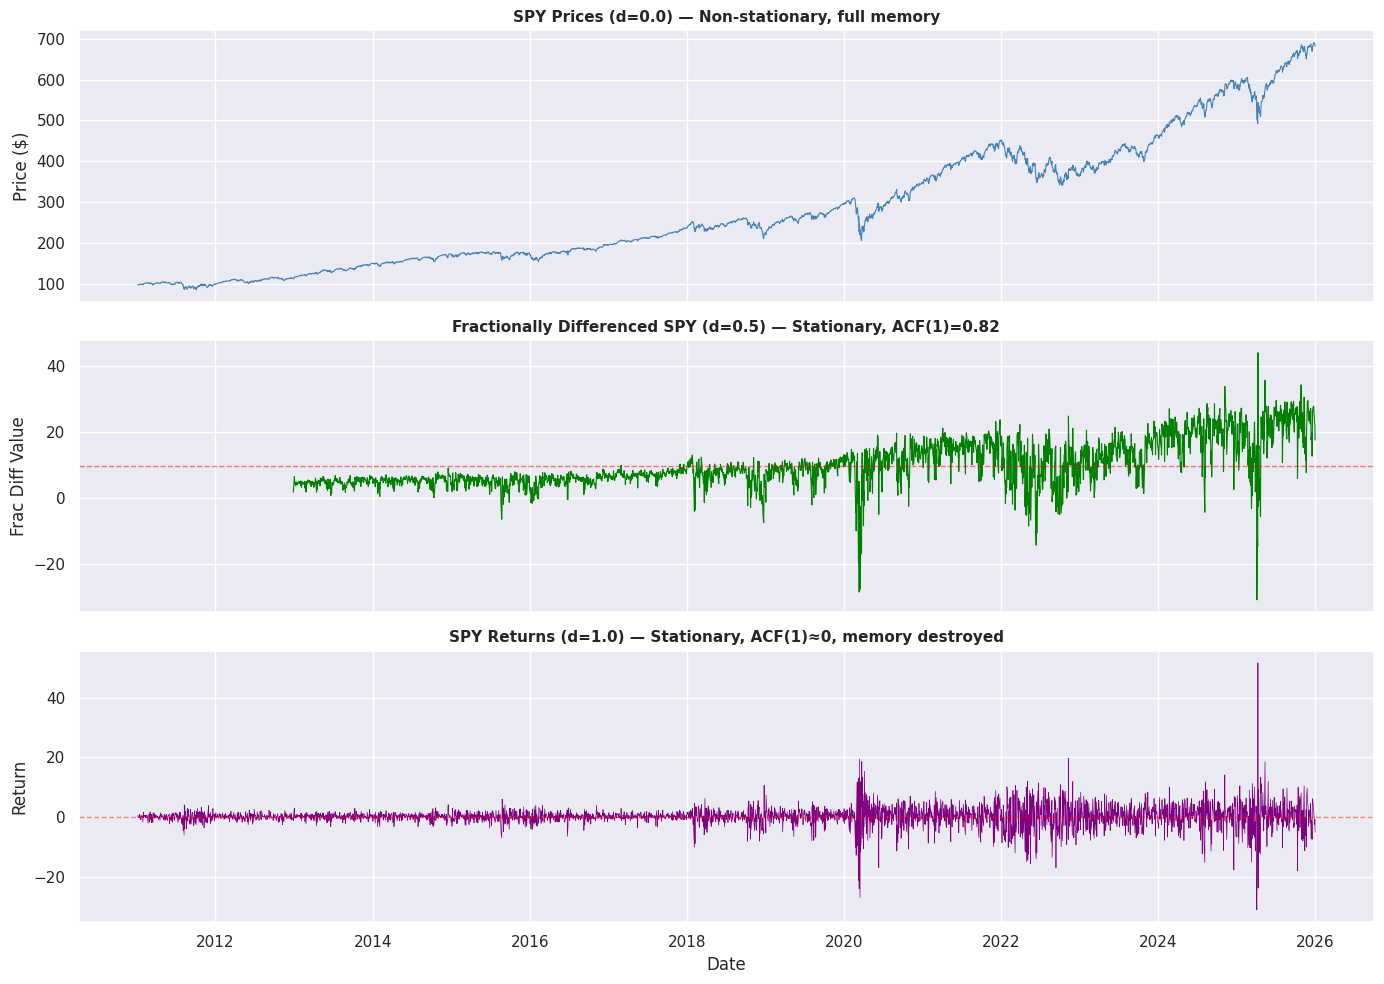

In [14]:
# --- Visualize fractionally differenced SPY at key d values ---
# We compare d=0 (raw prices), d=0.5 (minimum stationary), and d=1.0 (returns)
# to see how the series transforms as d increases

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# d=0: Raw prices (non-stationary)
axes[0].plot(spy_prices, color='steelblue', linewidth=0.8)
axes[0].set_title('SPY Prices (d=0.0) — Non-stationary, full memory',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Price ($)')

# d=0.5: Fractionally differenced (stationary, memory preserved)
fd_05 = frac_diff_results[0.5]['series'].dropna()
axes[1].plot(fd_05, color='green', linewidth=0.8)
axes[1].axhline(y=fd_05.mean(), color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Fractionally Differenced SPY (d=0.5) — Stationary, ACF(1)=0.82',
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frac Diff Value')

# d=1.0: Standard returns (stationary, memory destroyed)
fd_10 = frac_diff_results[1.0]['series'].dropna()
axes[2].plot(fd_10, color='purple', linewidth=0.5)
axes[2].axhline(y=fd_10.mean(), color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[2].set_title('SPY Returns (d=1.0) — Stationary, ACF(1)≈0, memory destroyed',
                   fontsize=11, fontweight='bold')
axes[2].set_ylabel('Return')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

The three panels show the transformation from raw prices to returns, with fractional differencing as the middle ground.

**Top panel (d=0.0, raw prices)**: The familiar SPY price chart trending from $100 to $700. Completely non-stationary, full of memory, but unusable as a direct input for most models.

**Middle panel (d=0.5, fractionally differenced)**: This is the key result. The series fluctuates around a mean (red dashed line) like a stationary process should, but it retains visible structure. You can see that it trends upward in bull markets and dips sharply during crises (the COVID drop to -25 is clearly visible). The series "remembers" price level information: after the COVID drop, it recovers toward its prior range. This memory is exactly what ACF(1) = 0.82 captures. The values themselves are not prices or returns — they are a hybrid that blends level information with change information.

**Bottom panel (d=1.0, standard returns)**: Stationary, centered tightly around zero, with no visible structure except the volatility clustering during crises. Each observation is essentially independent of the next. The price history that drove the top panel from $100 to $700 has been completely erased. A machine learning model looking at this series would see no connection between today's return and yesterday's return.

The visual difference between the middle and bottom panels is the difference between a feature that retains predictive information and one that has been stripped clean. For a model trying to predict whether SPY is likely to continue rising or is overextended, the fractionally differenced series at d=0.5 provides context that returns cannot.

**Practical guidance:** Fractional differencing is not a signal processing filter like Kalman or wavelets. It is a feature engineering technique. You would not use it to smooth VIX or generate a direct trading signal. You would use it to create input features for a machine learning model that need to be stationary (a requirement for most ML algorithms) while preserving as much information as possible from the original price series. When we build ML-based strategies in Chapters 13-14, fractionally differenced prices will be one of our most valuable feature transformations. The d=0.5 result we found here gives us a concrete starting point for SPY. Other instruments will have different minimum d values — VIX, being already stationary, would need d close to zero.

## Section 6: Boundary and End Effects Demonstration

This is the most practically important section in this notebook. Everything we have demonstrated so far was computed on the full dataset — all 3,771 trading days processed at once. In live trading, you do not have the full dataset. You have data up to today, and you need to generate a signal for tomorrow. When new data arrives tomorrow, you recompute your filters, and the question is: how much do the "historical" filtered values change?

If a filter is causal (only uses past and present data), the historical values should not change at all. If a filter uses future data (even implicitly, as batch processors like FFT and DWT do), adding new observations will alter the filtered values for dates that already passed. This means your backtest, which computed filtered values using the full sample, saw a different signal than your live system would see at each point in time.

This is not a theoretical concern. It is a form of lookahead bias that is invisible in standard backtesting and can make a mediocre strategy look good or a good strategy look mediocre, depending on how the boundary effects interact with your signal logic.

We demonstrate this concretely: apply each technique to VIX with and without the last 5 trading days, and measure how much the historical filtered values change.

### 6.1 The Experiment

We take our VIX series and split it into two versions:

- **Full series**: All 3,771 days (what a backtest would use)
- **Truncated series**: All days except the last 5 (what your live system would have seen 5 days ago)

We apply Kalman, Fourier, and wavelet filtering to both versions, then compare the filtered values for the overlapping dates. The difference reveals how much each technique's output is contaminated by future information.

In [15]:
# --- Boundary effects experiment setup ---
# We split VIX into two versions:
#   - full: the complete series (simulates backtest with full hindsight)
#   - truncated: everything except the last 5 days (simulates live trading 5 days ago)
# Then we apply each filter to both and compare the overlapping period.

n_new = 5  # Number of "new" days to add
vix_full = vix.copy()
vix_truncated = vix.iloc[:-n_new].copy()

# Define the comparison window: the last 30 days of the truncated series
# These are dates that exist in BOTH versions, so any difference in filtered
# values is purely due to the 5 new observations influencing the filter
compare_start = -30 - n_new  # 30 days before the truncation point
compare_end = -n_new         # The truncation point

print(f"Full series: {len(vix_full)} days, ends {vix_full.index[-1].strftime('%Y-%m-%d')}")
print(f"Truncated series: {len(vix_truncated)} days, ends {vix_truncated.index[-1].strftime('%Y-%m-%d')}")
print(f"\nComparison window: last 30 days of truncated series")
print(f"  From: {vix_full.index[compare_start].strftime('%Y-%m-%d')}")
print(f"  To:   {vix_full.index[compare_end - 1].strftime('%Y-%m-%d')}")
print(f"\nQuestion: do the filtered values for these 30 days change")
print(f"when we add {n_new} new observations after them?")

Full series: 3771 days, ends 2025-12-31
Truncated series: 3766 days, ends 2025-12-23

Comparison window: last 30 days of truncated series
  From: 2025-11-11
  To:   2025-12-23

Question: do the filtered values for these 30 days change
when we add 5 new observations after them?


Good. Now let us apply all three filters to both versions and measure the damage.

In [16]:
# --- Apply each filter to both full and truncated series ---

# 1. Kalman filter (Q=0.01, R=1.0 — our baseline from Section 2)
kalman_full = apply_kalman_filter(vix_full, process_noise=0.01, measurement_noise=1.0)
kalman_trunc = apply_kalman_filter(vix_truncated, process_noise=0.01, measurement_noise=1.0)

# 2. Fourier low-pass filter (keep periods > 90 days)
fourier_full = fourier_lowpass(vix_full, min_period=90)
fourier_trunc = fourier_lowpass(vix_truncated, min_period=90)

# 3. Wavelet denoising (standard threshold)
wavelet_full = wavelet_denoise(vix_full, threshold_multiplier=1.0)
wavelet_trunc = wavelet_denoise(vix_truncated, threshold_multiplier=1.0)

# --- Extract the comparison window from each ---
# For full series: use the same date range as the truncated comparison window
compare_dates = vix_full.index[compare_start:compare_end]

# Kalman: align by date index
kalman_full_window = kalman_full.loc[compare_dates]
kalman_trunc_window = kalman_trunc.loc[compare_dates]

# Fourier: align by date index
fourier_full_window = fourier_full.loc[compare_dates]
fourier_trunc_window = fourier_trunc.loc[compare_dates]

# Wavelet: align by date index
wavelet_full_window = wavelet_full.loc[compare_dates]
wavelet_trunc_window = wavelet_trunc.loc[compare_dates]

# --- Calculate differences ---
kalman_diff = (kalman_full_window.values - kalman_trunc_window.values)
fourier_diff = (fourier_full_window.values - fourier_trunc_window.values)
wavelet_diff = (wavelet_full_window.values - wavelet_trunc_window.values)

# --- Summary statistics ---
print("Boundary Effects: How Much Do Historical Filtered Values Change?")
print("=" * 70)
print(f"\nWhen 5 new trading days are added to the end of the series,")
print(f"how much do the filtered values for the prior 30 days change?\n")
print(f"{'Filter':<20} {'Mean Abs Diff':>14} {'Max Abs Diff':>14} {'Std of Diff':>14}")
print("-" * 70)
print(f"{'Kalman':<20} {np.abs(kalman_diff).mean():>14.6f} "
      f"{np.abs(kalman_diff).max():>14.6f} {kalman_diff.std():>14.6f}")
print(f"{'Fourier (>90 day)':<20} {np.abs(fourier_diff).mean():>14.6f} "
      f"{np.abs(fourier_diff).max():>14.6f} {fourier_diff.std():>14.6f}")
print(f"{'Wavelet (standard)':<20} {np.abs(wavelet_diff).mean():>14.6f} "
      f"{np.abs(wavelet_diff).max():>14.6f} {wavelet_diff.std():>14.6f}")

Boundary Effects: How Much Do Historical Filtered Values Change?

When 5 new trading days are added to the end of the series,
how much do the filtered values for the prior 30 days change?

Filter                Mean Abs Diff   Max Abs Diff    Std of Diff
----------------------------------------------------------------------
Kalman                     0.000000       0.000000       0.000000
Fourier (>90 day)          0.140256       0.366415       0.116210
Wavelet (standard)         0.226512       0.930334       0.315398


The numbers speak for themselves.

**Kalman filter: zero change.** Exactly zero, to six decimal places. Adding 5 new days of data did not change a single historical filtered value by even a millionth of a VIX point. This is the causal property in action. The Kalman filter at time t only uses data from times 1 through t. Future observations are structurally irrelevant. What you see in a backtest is exactly what you would see in live trading. This is a fundamental advantage.

**Fourier filter: moderate change.** Historical values shifted by an average of 0.14 VIX points, with a maximum shift of 0.37 points. This may sound small, but consider that our VIXY strategy triggers when realized volatility exceeds the VIX moving average. If the filtered VIX value at a given date is 0.37 points different in your backtest than it would have been in live trading, that could flip the signal on a borderline day. Over thousands of trading days, these small shifts accumulate into meaningful differences between backtested and live performance.

**Wavelet denoising: largest change.** Historical values shifted by an average of 0.23 VIX points, with a maximum shift of 0.93 points — nearly a full VIX point. The wavelet denoised value for a date in late November 2025 changed by almost one point just because five new December observations were added. This is the boundary padding problem we discussed in the chapter outline. The DWT needs to pad the edges, and changing the edge data changes the padding, which propagates inward.

Let us visualize these differences to make the problem tangible.

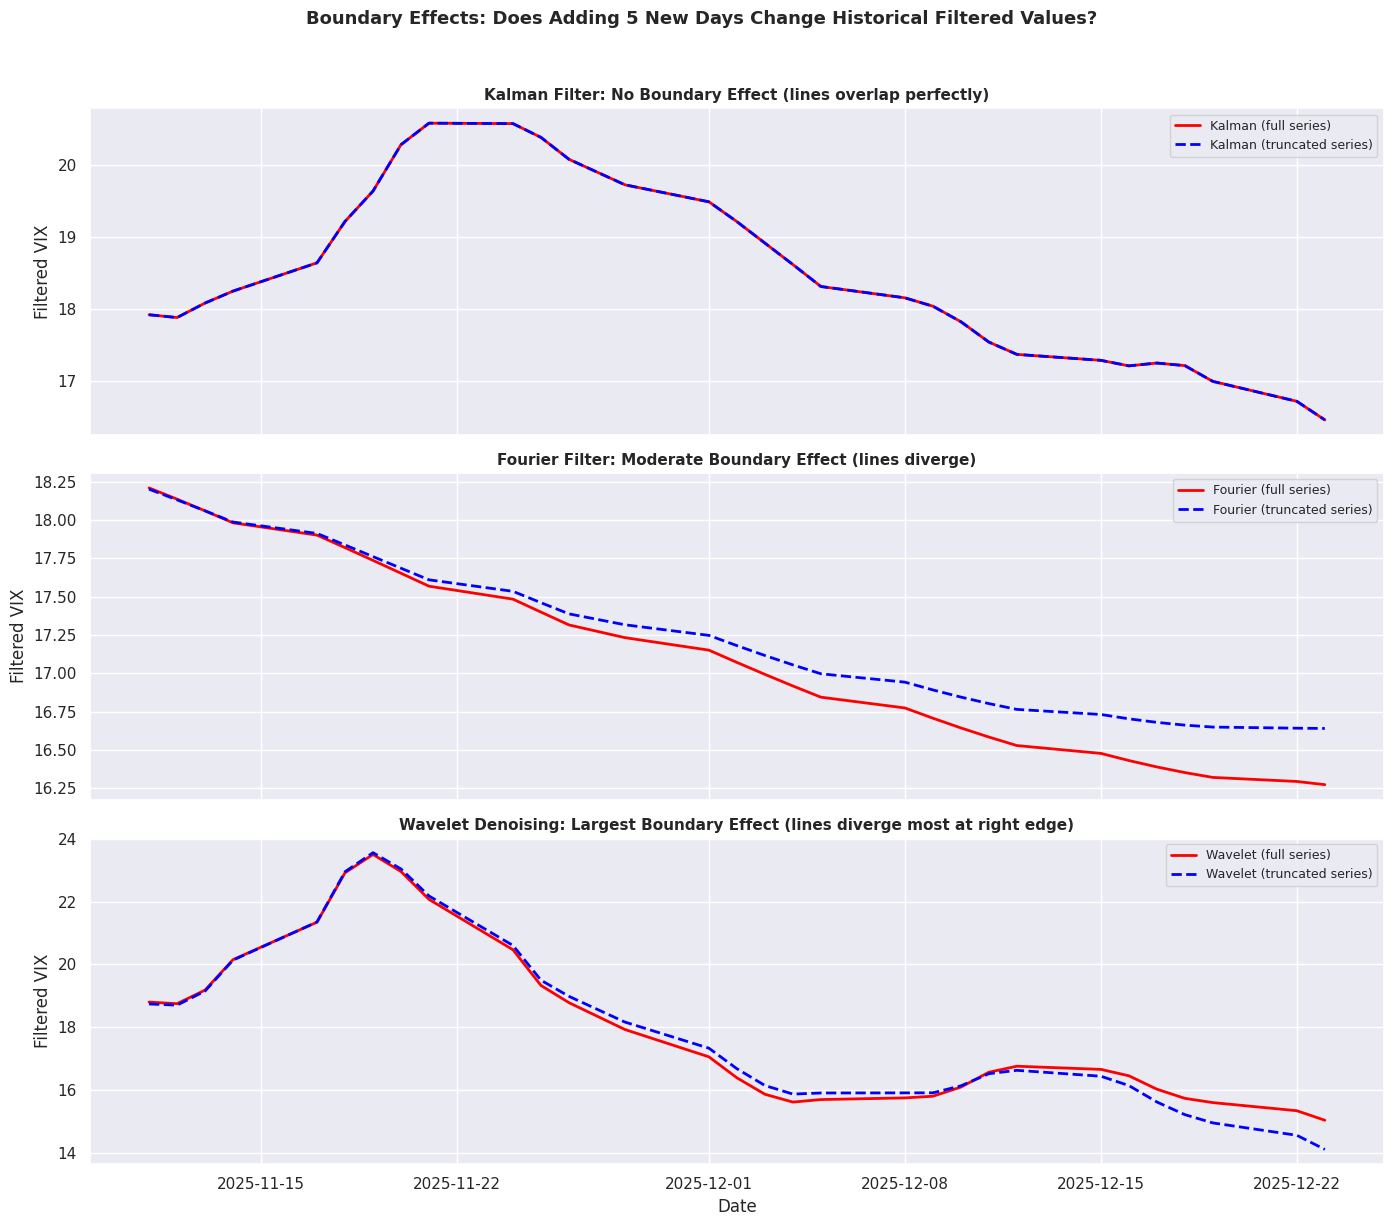

In [17]:
# --- Visualize the boundary effects ---
# Three panels showing full vs. truncated filtered values for each technique

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Panel 1: Kalman
axes[0].plot(compare_dates, kalman_full_window.values, color='red', linewidth=2,
             label='Kalman (full series)')
axes[0].plot(compare_dates, kalman_trunc_window.values, color='blue', linewidth=2,
             linestyle='--', label='Kalman (truncated series)')
axes[0].set_title('Kalman Filter: No Boundary Effect (lines overlap perfectly)',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Filtered VIX')
axes[0].legend(fontsize=9)

# Panel 2: Fourier
axes[1].plot(compare_dates, fourier_full_window.values, color='red', linewidth=2,
             label='Fourier (full series)')
axes[1].plot(compare_dates, fourier_trunc_window.values, color='blue', linewidth=2,
             linestyle='--', label='Fourier (truncated series)')
axes[1].set_title('Fourier Filter: Moderate Boundary Effect (lines diverge)',
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel('Filtered VIX')
axes[1].legend(fontsize=9)

# Panel 3: Wavelet
axes[2].plot(compare_dates, wavelet_full_window.values, color='red', linewidth=2,
             label='Wavelet (full series)')
axes[2].plot(compare_dates, wavelet_trunc_window.values, color='blue', linewidth=2,
             linestyle='--', label='Wavelet (truncated series)')
axes[2].set_title('Wavelet Denoising: Largest Boundary Effect (lines diverge most at right edge)',
                   fontsize=11, fontweight='bold')
axes[2].set_ylabel('Filtered VIX')
axes[2].set_xlabel('Date')
axes[2].legend(fontsize=9)

plt.suptitle('Boundary Effects: Does Adding 5 New Days Change Historical Filtered Values?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This visualization makes the boundary effects problem undeniable.

**Kalman (top panel)**: The red and blue lines are identical. You cannot distinguish them because there is literally no difference. Every filtered value computed with the truncated series is exactly the same as the value computed with the full series. If you deployed a Kalman filter in live trading, your historical signal values would never change as new data arrives. Your backtest and your live system see the same thing.

**Fourier (middle panel)**: The lines start close together on the left (mid-November) and gradually diverge toward the right edge (late December). By December 22, the gap is roughly 0.3-0.4 VIX points. The divergence gets worse as you approach the end of the series, which is exactly where you are making trading decisions. Notice that the truncated version (blue dashed) sits consistently above the full version (red). This means your live system five days ago was seeing a higher filtered VIX than your backtest says it should have been. Depending on your signal threshold, this could have flipped the hedge signal.

**Wavelet (bottom panel)**: The divergence is the most dramatic. The lines are close in mid-November (left side) but separate substantially toward the right. At the truncation point around December 23, the gap is nearly a full VIX point: the truncated version shows roughly 14.1 while the full version shows about 14.9. But also look at mid-to-late November: even 30 days before the new data was added, the wavelet values shifted visibly. The boundary effect propagates backward further than Fourier's does.

**The implication for backtesting:** If you use Fourier or wavelet filtering in a backtest, the filtered signal your backtest evaluates is not the signal your live system would have generated. Your backtest uses the full-sample filter (red lines), but your live system would have been operating on the truncated filter (blue lines). Every day that new data arrives, the right edge of your filter shifts. The strategy decisions your backtest attributes to specific dates are based on filter values that would not have existed at those dates. This is lookahead bias introduced by the filter itself, and it is extremely difficult to detect unless you specifically test for it as we just did.

**Practical guidance:** If you want to use Fourier or wavelet filtering in a live trading system, you must backtest them in a rolling fashion: at each date, apply the filter using only data available up to that date. This is computationally expensive (you recompute the FFT or DWT at every step) and it will produce different results than a naive full-sample backtest. If the strategy looks good with full-sample filtering but falls apart with rolling filtering, the boundary effects were carrying the performance. The Kalman filter and fractional differencing avoid this problem entirely by design.

## Section 7: Side-by-Side Comparison

We have now applied four different signal processing techniques to VIX. Before we move to Notebook 6.4 where we test whether any of these improve strategy performance, let us put them all on the same chart for a direct visual comparison. We also include the 90-day SMA as the baseline that any advanced technique needs to beat.

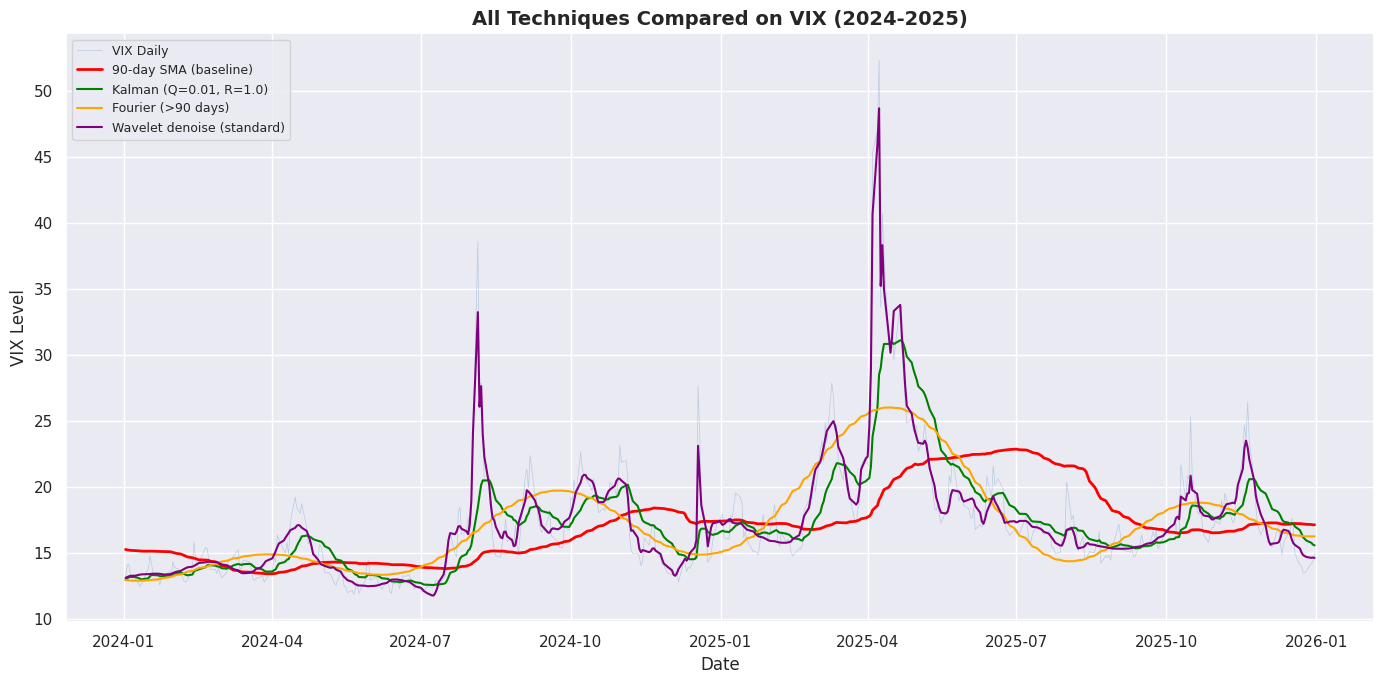

In [18]:
# --- Side-by-side comparison of all techniques on VIX ---
# We use the baseline parameter settings from each section:
#   - 90-day SMA (our strategy's current filter)
#   - Kalman (Q=0.01, R=1.0)
#   - Fourier low-pass (keep periods > 90 days)
#   - Wavelet denoising (standard threshold, 1.0x)
# Fractional differencing is excluded here because it produces
# a different scale (not directly comparable as a VIX filter)

# Zoom into 2024-2025 for a recent, detailed comparison
mask = (vix.index >= '2024-01-01') & (vix.index <= '2025-12-31')

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(vix[mask], color='steelblue', linewidth=0.5, alpha=0.3, label='VIX Daily')
ax.plot(vix_sma_90[mask], color='red', linewidth=2, label='90-day SMA (baseline)')
ax.plot(vix_kalman[mask], color='green', linewidth=1.5, label='Kalman (Q=0.01, R=1.0)')
ax.plot(vix_fourier_90[mask], color='orange', linewidth=1.5, label='Fourier (>90 days)')
ax.plot(vix_denoise_standard[mask], color='purple', linewidth=1.5,
        label='Wavelet denoise (standard)')

ax.set_title('All Techniques Compared on VIX (2024-2025)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('VIX Level')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

This chart reveals the personality of each filter.

**90-day SMA (red)**: The slowest to react. It barely moves during the August 2024 VIX spike to 39, reaching only about 15 before the spike had already passed. During the April 2025 spike to 52, it climbs to roughly 22 — less than half the actual VIX level — and it gets there weeks after the event. It is the smoothest and most stable line on the chart, which is both its strength (few false signals) and its weakness (slow to recognize regime changes).

**Kalman (green)**: The most responsive of the group. It tracks VIX spikes closely, reaching about 33 during the August 2024 event and above 30 during April 2025. It reacts within days rather than weeks. But it also reacts to every moderate fluctuation throughout 2024, oscillating between 13 and 20 in ways the SMA ignores. It is the only technique here with zero boundary effects, which makes it the most trustworthy for live deployment despite its noisier output.

**Fourier (orange)**: Produces a smooth, gently undulating curve that looks elegant but behaves strangely. It appears to anticipate the April 2025 spike, rising before VIX does — this is the lookahead bias we demonstrated in Section 6. The Fourier filter computed on the full dataset "knows" about the spike and adjusts its filtered values before the spike occurs. In live trading, this early rise would not exist. The smooth shape is an illusion of batch processing.

**Wavelet (purple)**: The most interesting behavior. It preserves the sharp structure of both the August 2024 and April 2025 spikes far better than the SMA or Fourier, reaching 33 and 47 respectively. It strips away daily noise while keeping the dramatic shape of events intact. However, as we showed in Section 6, these values would shift somewhat in live trading due to boundary effects. The wavelet output you see here is the full-sample version, which is slightly more favorable than what a rolling implementation would produce.

**The key observation:** No single technique dominates. The SMA is the most trustworthy (causal, simple, stable) but the least responsive. The Kalman filter is the most responsive and boundary-safe but the noisiest. The wavelet produces the most visually appealing results but has boundary issues. The Fourier filter has the most serious problems (lookahead bias, ringing artifacts) and offers the least practical advantage over simpler alternatives.

Whether any of these filters improve actual strategy performance over the simple SMA is the question for Notebook 6.4.

## Section 8: Summary and Key Takeaways

This notebook explored four advanced signal processing techniques on our case study data. Here is what we learned about each.

In [19]:
# --- Final summary table ---
summary = {
    'Technique': [
        'Kalman Filter',
        'Fourier Transform',
        'Wavelet Denoising',
        'Fractional Differencing'
    ],
    'What It Does': [
        'Adaptive smoothing (smart MA)',
        'Frequency-domain filtering',
        'Multi-scale decomposition and denoising',
        'Stationarity with memory preservation'
    ],
    'Boundary Effects': [
        'None (causal)',
        'Significant (batch process)',
        'Moderate (padding dependent)',
        'None (backward-looking)'
    ],
    'Parameter Sensitivity': [
        'High (Q/R ratio)',
        'Moderate (cutoff period)',
        'Low (threshold stable)',
        'Low (d chosen by ADF test)'
    ],
    'Best Use Case': [
        'Live signal smoothing, state estimation',
        'Offline analysis, intraday patterns',
        'Multi-scale analysis, regime research',
        'ML feature engineering (Ch. 13-14)'
    ]
}

df_summary = pd.DataFrame(summary).set_index('Technique')
print("Summary: Advanced Signal Processing Techniques")
print("=" * 165)
print(df_summary.to_string())

Summary: Advanced Signal Processing Techniques
                                                    What It Does              Boundary Effects       Parameter Sensitivity                            Best Use Case
Technique                                                                                                                                                          
Kalman Filter                      Adaptive smoothing (smart MA)                 None (causal)            High (Q/R ratio)  Live signal smoothing, state estimation
Fourier Transform                     Frequency-domain filtering   Significant (batch process)    Moderate (cutoff period)      Offline analysis, intraday patterns
Wavelet Denoising        Multi-scale decomposition and denoising  Moderate (padding dependent)      Low (threshold stable)    Multi-scale analysis, regime research
Fractional Differencing    Stationarity with memory preservation       None (backward-looking)  Low (d chosen by ADF test)       ML f

This table is your reference card for choosing between techniques. Two dimensions matter most for practical trading applications: boundary effects and parameter sensitivity.

**Boundary effects** determine whether you can trust the technique in live trading. Kalman and fractional differencing are causal — they produce the same output whether you compute them today or recompute them next week with more data. Fourier and wavelets are batch processors that will give you different historical values every time you add new data. If you must use Fourier or wavelets in a live system, you need to backtest them with rolling recomputation, not full-sample filtering.

**Parameter sensitivity** determines how robust your results are to your specific choices. The wavelet denoising was surprisingly stable across a range of threshold values. Fractional differencing has a principled way to choose d (the minimum value that achieves stationarity). The Kalman filter, by contrast, can produce dramatically different outputs depending on Q and R, and there is no theoretical basis for choosing these parameters on financial data. This makes the Kalman filter powerful but dangerous: it is easy to find Q/R settings that look great in a backtest but reflect overfitting rather than genuine signal extraction.

**Fractional differencing** stands apart from the other three. It is not a smoother or a denoiser — it is a transformation that solves a specific problem (stationarity without memory loss) that the other techniques do not address. Its primary value is for machine learning feature engineering, which we will explore in Chapters 13-14. The minimum d of 0.5 we found for SPY gives us a concrete starting point.

In Notebook 6.4, we put this to the ultimate test: we run our VIXY tail hedge strategy with each of these filtered VIX signals and measure whether the added complexity produces better risk-adjusted returns than the simple 90-day SMA. The bar is clear, and based on what we have seen in this notebook, clearing it will not be easy.